# Library dan Konfigurasi

## Import Library

In [1]:
import ast
import io
import json
import os
import re
import shutil
import subprocess
import sys
import stat
import time
import tokenize
from collections import defaultdict
from datetime import datetime
import pickle
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import normalize

# Formatter untuk standarisasi kode Python
import autopep8
import black

# Engine export Excel untuk pandas
import openpyxl

# Progress bar & notebook display
from tqdm.notebook import tqdm
from IPython.display import display, HTML

# Waktu
run_time = datetime.now()

# Konfigurasi visualisasi default
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

print("=" * 65)
print(f"{'LIBRARY INITIALIZATION':^65}")
print("-" * 65)
print(f"Python     : {sys.version.split()[0]}")
print(f"✅ {run_time.strftime('%Y-%m-%d %H:%M:%S')} - Libraries loaded successfully.")
print("-" * 65)

                     LIBRARY INITIALIZATION                      
-----------------------------------------------------------------
Python     : 3.10.6
✅ 2026-06-24 21:43:52 - Libraries loaded successfully.
-----------------------------------------------------------------


## Konfigurasi

In [2]:
# ==============================================================================
# DIRECTORY CONFIGURATION & INITIALIZATION
# Menentukan path utama, struktur folder dataset, dan file output
# ==============================================================================

# Root directory dan file input
BASE_DIR = r"D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code"
DATASET_FOLDER = "dataset(2)"
OUTPUT_FOLDER = "output(2)"

INPUT_GITHUB = os.path.join(BASE_DIR, "asli", "nim_github.txt")

# Struktur folder pipeline
DIRS = {
    "DATASET"      : os.path.join(BASE_DIR, DATASET_FOLDER),

    # Preprocessing
    "RAW"          : os.path.join(BASE_DIR, DATASET_FOLDER, "00_Raw"),
    "ANON"          : os.path.join(BASE_DIR, DATASET_FOLDER, "01_Raw_Anon"),
    "NORM"         : os.path.join(BASE_DIR, DATASET_FOLDER, "02_Normalized"),
    "CONV"         : os.path.join(BASE_DIR, DATASET_FOLDER, "03_Converted"),
    "CLEAN"        : os.path.join(BASE_DIR, DATASET_FOLDER, "04_Cleaned"),

    # Formatter experiment
    "AUTOPEP8"     : os.path.join(BASE_DIR, DATASET_FOLDER, "05a_Autopep8"),
    "BLACK"        : os.path.join(BASE_DIR, DATASET_FOLDER, "05b_Black"),
    
    "FILTERED"     : os.path.join(BASE_DIR, DATASET_FOLDER, "06_Filtered"),
    "FILTERED_PRAK"     : os.path.join(BASE_DIR, DATASET_FOLDER, "06_Filtered_prak"),
    "FILTERED_TGS"     : os.path.join(BASE_DIR, DATASET_FOLDER, "06_Filtered_tgs"),

    # AST & Graph
    "AST_P"          : os.path.join(BASE_DIR, DATASET_FOLDER, "07_AST_prak"),
    "AST_T"          : os.path.join(BASE_DIR, DATASET_FOLDER, "07_AST_tgs"),
    "AST_VISUAL_P"   : os.path.join(BASE_DIR, DATASET_FOLDER, "07a_AST_visual_prak"),
    "AST_VISUAL_T"   : os.path.join(BASE_DIR, DATASET_FOLDER, "07a_AST_visual_tgs"),
    "GRAPH_P"        : os.path.join(BASE_DIR, DATASET_FOLDER, "08_Graph_prak"),
    "GRAPH_T"        : os.path.join(BASE_DIR, DATASET_FOLDER, "08_Graph_tgs"),
    "INPUT_GRAPH_P"  : os.path.join(BASE_DIR, DATASET_FOLDER, "09_Graph2vec_Input_prak"),
    "INPUT_GRAPH_T"  : os.path.join(BASE_DIR, DATASET_FOLDER, "09_Graph2vec_Input_tgs"),
    "EMBEDDING_P"    : os.path.join(BASE_DIR, DATASET_FOLDER, "10_Graph2vec_Embedding_prak"),
    "EMBEDDING_T"    : os.path.join(BASE_DIR, DATASET_FOLDER, "10_Graph2vec_Embedding_tgs"),

    # Output
    "LOGS"         : os.path.join(BASE_DIR, OUTPUT_FOLDER),
    "RUNTIME_A"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_autopep8"),
    "RUNTIME_B"    : os.path.join(BASE_DIR, OUTPUT_FOLDER, "run_black"),
    "EVAL"         : os.path.join(BASE_DIR, OUTPUT_FOLDER, "eval"),
    "EVAL_P"       : os.path.join(BASE_DIR, OUTPUT_FOLDER, "eval", "praktikum"),
    "EVAL_T"       : os.path.join(BASE_DIR, OUTPUT_FOLDER, "eval", "tugas"),
    
    # folder output untuk grafik similarity
    "SIMILARITY"   : os.path.join(BASE_DIR, OUTPUT_FOLDER,"similarity"),
}

# File output penelitian
RESULTS = {
    # Preprocessing
    "CLONE_REPORT"    : os.path.join(DIRS["LOGS"], "01_clone_report.xlsx"),
    "NORM_REPORT"     : os.path.join(DIRS["LOGS"], "02_normalization_report.xlsx"),
    "CONV_REPORT"     : os.path.join(DIRS["LOGS"], "03_conversion_report.xlsx"),
    "CLEAN_REPORT"    : os.path.join(DIRS["LOGS"], "04_cleaning_report.xlsx"),

    # Formatter
    "ERR_AUTOPEP"     : os.path.join(DIRS["LOGS"], "05a_autopep_errors.json"),
    "ERR_BLACK"       : os.path.join(DIRS["LOGS"], "05b_black_errors.json"),

    # Runtime Autopep8
    "RUN_PROJECT_A"   : os.path.join(DIRS["RUNTIME_A"], "a_runtime_project_AUTOPEP8.xlsx"),
    "RUN_FUNCTION_A"  : os.path.join(DIRS["RUNTIME_A"], "b_runtime_function_AUTOPEP8.xlsx"),
    "RUN_COMPARE_A"   : os.path.join(DIRS["RUNTIME_A"], "c_runtime_compare_AUTOPEP8.xlsx"),

    # Runtime Black
    "RUN_PROJECT_B"   : os.path.join(DIRS["RUNTIME_B"], "a_runtime_project_BLACK.xlsx"),
    "RUN_FUNCTION_B"  : os.path.join(DIRS["RUNTIME_B"], "b_runtime_function_BLACK.xlsx"),
    "RUN_COMPARE_B"   : os.path.join(DIRS["RUNTIME_B"], "c_runtime_compare_BLACK.xlsx"),

    # Submission
    "SUBMISSION"      : os.path.join(DIRS["LOGS"], "06_submission_report.xlsx"),

    # AST & Graph
    "EXTRACT_AST_P"     : os.path.join(DIRS["LOGS"], "07_AST_report_prak.xlsx"),
    "EXTRACT_AST_T"     : os.path.join(DIRS["LOGS"], "07_AST_report_tgs.xlsx"),
    "CONSTRUCT_GRAPH_P" : os.path.join(DIRS["LOGS"], "08_Graph_report_prak.xlsx"),
    "CONSTRUCT_GRAPH_T" : os.path.join(DIRS["LOGS"], "08_Graph_report_tgs.xlsx"),
    "LIST_GRAPH_P"      : os.path.join(DIRS["LOGS"], "09_list_Graph_report_prak.xlsx"),
    "LIST_GRAPH_T"      : os.path.join(DIRS["LOGS"], "09_list_Graph_report_tgs.xlsx"),

    # Graph2Vec
    "EMBEDDING_REPORT_P": os.path.join(DIRS["LOGS"], "10_embedding_report_prak.xlsx"),
    "EMBEDDING_REPORT_T": os.path.join(DIRS["LOGS"], "10_embedding_report_tgs.xlsx"),
    "EMBEDDING_VECTOR_P": os.path.join(DIRS["LOGS"], "10a_embedding_vector_prak.xlsx"),
    "EMBEDDING_VECTOR_T": os.path.join(DIRS["LOGS"], "10a_embedding_vector_tgs.xlsx"),

    # Similarity PRAKTIKUM
    "SIMILARITY_P"      : os.path.join(DIRS["LOGS"], "11_similarity_report_prak.xlsx"),
    "SIMILARITY_MODUL_P" : os.path.join(DIRS['LOGS'], "11a_similarity_per_Modul_prak.xlsx"),
    "SIMILARITY_SUMMARY_P" : os.path.join(DIRS['LOGS'], "11b_similarity_summary_prak.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN_P" : os.path.join(DIRS['LOGS'], "12_euclidean_similarity_prak.xlsx"),
    "EUCLIDEAN_MODUL_P" : os.path.join(DIRS['LOGS'], "12a_euclidean_similarity_modul_prak.xlsx"),
    
    "SIMILARITY_COMPARE_P" : os.path.join(DIRS['LOGS'], "13_similarity_comparison_prak.xlsx"),
    
    # Similarity TUGAS
    "SIMILARITY_T"      : os.path.join(DIRS["LOGS"], "11_similarity_report_tgs.xlsx"),
    "SIMILARITY_MODUL_T" : os.path.join(DIRS['LOGS'], "11a_similarity_per_Modul_tgs.xlsx"),
    "SIMILARITY_SUMMARY_T" : os.path.join(DIRS['LOGS'], "11b_similarity_summary_tgs.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN_T" : os.path.join(DIRS['LOGS'], "12_euclidean_similarity_tgs.xlsx"),
    "EUCLIDEAN_MODUL_T" : os.path.join(DIRS['LOGS'], "12a_euclidean_similarity_modul_tgs.xlsx"),
    
    "SIMILARITY_COMPARE_T" : os.path.join(DIRS['LOGS'], "13_similarity_comparison_tgs.xlsx"),
    
    # METRICS
    "METRICS"         : os.path.join(DIRS["LOGS"], "metrics_evaluation_report.xlsx"),
    "EXECUTION_TIME"  : os.path.join(DIRS["LOGS"], "execution_time_report.xlsx"),
}

# VALIDATION & DIRECTORY INITIALIZATION
print("=" * 70)
print(f"{'DIRECTORY CONFIGURATION':^70}")
print("=" * 70)

# Validasi root directory
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(f"❌ BASE_DIR tidak ditemukan: {BASE_DIR}")

# Validasi file input
if not os.path.isfile(INPUT_GITHUB):
    raise FileNotFoundError(f"❌ File input tidak ditemukan: {INPUT_GITHUB}")

if not INPUT_GITHUB.endswith(".txt"):
    raise ValueError("❌ File input harus berekstensi .txt")

if os.path.getsize(INPUT_GITHUB) == 0:
    raise ValueError(f"❌ File input kosong: {INPUT_GITHUB}")

# Membuat folder pipeline
folders_created = 0

for name, path in DIRS.items():
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        folders_created += 1
        status = "[NEW]"
    elif not os.path.isdir(path):
        raise NotADirectoryError(f"❌ Path bukan folder: {path}")
    else:
        status = "[EXISTS]"
    print(f"{status:<10} {name:<12} : {path}")

# Validasi parent folder output
missing_results_parent = []

for name, path in RESULTS.items():
    parent_dir = os.path.dirname(path)
    if not os.path.exists(parent_dir):
        missing_results_parent.append(
            f"{name} : {parent_dir}"
        )

if missing_results_parent:
    raise FileNotFoundError(
        "❌ Parent folder RESULTS tidak ditemukan:\n"
        + "\n".join(missing_results_parent)
    )

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("-" * 70)
print(f"Folders Created  : {folders_created}")
print(f"Dataset Root     : {DIRS['DATASET']}")
print(f"Input File       : {INPUT_GITHUB}")
print("=" * 70)
print(f"Diproses pada {timestamp}")

                       DIRECTORY CONFIGURATION                        
[EXISTS]   DATASET      : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)
[EXISTS]   RAW          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\00_Raw
[EXISTS]   ANON         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\01_Raw_Anon
[EXISTS]   NORM         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\02_Normalized
[EXISTS]   CONV         : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\03_Converted
[EXISTS]   CLEAN        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\04_Cleaned
[EXISTS]   AUTOPEP8     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05a_Autopep8
[EXISTS]   BLACK        : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\05b_Black
[EXISTS]   FILTERED     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\06_Filtered
[EXISTS]   FILTERED_PRAK : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\06_Filtered_prak
[EXISTS]   FILTERED_TGS : D:\PUTRI\D4\S

In [3]:
# ==============================================================================
# EVALUATION CONFIG DIR
# ==============================================================================
DATASET_EVAL_FOLDER = DATASET_FOLDER + "_eval"
DATASET_EVAL_DIR = os.path.join(BASE_DIR, DATASET_EVAL_FOLDER)
DATASET_EVAL_P = os.path.join(DATASET_EVAL_DIR, "praktikum")
DATASET_EVAL_T = os.path.join(DATASET_EVAL_DIR, "tugas")

EVAL_P = {
    # PRAKTIKUM
    "SAMPLE"       : os.path.join(DATASET_EVAL_P, "06_SAMPLE"),
    "AST"          : os.path.join(DATASET_EVAL_P, "07_AST"),
    "AST_VISUAL"   : os.path.join(DATASET_EVAL_P, "07a_AST_visual"),
    "GRAPH"        : os.path.join(DATASET_EVAL_P, "08_Graph"),
    "INPUT_GRAPH"  : os.path.join(DATASET_EVAL_P, "09_Graph2vec_Input"),
    "EMBEDDING"    : os.path.join(DATASET_EVAL_P, "10_Graph2vec_Embedding"),
    "EMBEDDING_AST"    : os.path.join(DATASET_EVAL_P, "10a_AST_Embedding"),
    "EMBEDDING_G2V"    : os.path.join(DATASET_EVAL_P, "10b_G2V_Embedding"),
}

EVAL_T = {
    # TUGAS
    "SAMPLE"       : os.path.join(DATASET_EVAL_T, "06_SAMPLE"),
    "AST"          : os.path.join(DATASET_EVAL_T, "07_AST"),
    "AST_VISUAL"   : os.path.join(DATASET_EVAL_T, "07a_AST_visual"),
    "GRAPH"        : os.path.join(DATASET_EVAL_T, "08_Graph"),
    "INPUT_GRAPH"  : os.path.join(DATASET_EVAL_T, "09_Graph2vec_Input"),
    "EMBEDDING"    : os.path.join(DATASET_EVAL_T, "10_Graph2vec_Embedding"),
    "EMBEDDING_AST"    : os.path.join(DATASET_EVAL_T, "10a_AST_Embedding"),
    "EMBEDDING_G2V"    : os.path.join(DATASET_EVAL_T, "10b_G2V_Embedding"),
}

RESULTS_EVAL_P = {
    "SAMPLING_REPORT" : os.path.join(DIRS["EVAL_P"], "06_sampling_report.xlsx"),
    # AST & Graph
    "EXTRACT_AST"     : os.path.join(DIRS["EVAL_P"], "07_AST_report.xlsx"),
    "CONSTRUCT_GRAPH" : os.path.join(DIRS["EVAL_P"], "08_Graph_report.xlsx"),
    "LIST_GRAPH"      : os.path.join(DIRS["EVAL_P"], "09_list_Graph_report.xlsx"),

    # Graph2Vec+AST
    "EMBEDDING_REPORT": os.path.join(DIRS["EVAL_P"], "10_embedding_report.xlsx"),
    "EMBEDDING_VECTOR": os.path.join(DIRS["EVAL_P"], "10a_embedding_vector.xlsx"),
    # AST embedding
    "EMBEDDING_AST_REPORT": os.path.join(DIRS["EVAL_P"], "10_ast_embedding_report.xlsx"),
    "EMBEDDING_AST_VECTOR": os.path.join(DIRS["EVAL_P"], "10a_ast_embedding_vector.xlsx"),
    # G2V embedding
    "EMBEDDING_G2V_REPORT": os.path.join(DIRS["EVAL_P"], "10_g2v_embedding_report.xlsx"),
    "EMBEDDING_G2V_VECTOR": os.path.join(DIRS["EVAL_P"], "10a_g2v_embedding_vector.xlsx"),

    # Similarity
    "SIMILARITY"      : os.path.join(DIRS["EVAL_P"], "11_similarity_report.xlsx"),
    "SIMILARITY_MODUL" : os.path.join(DIRS['EVAL_P'], "11a_similarity_per_Modul.xlsx"),
    "SIMILARITY_SUMMARY" : os.path.join(DIRS['EVAL_P'], "11b_similarity_summary.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN" : os.path.join(DIRS['EVAL_P'], "12_euclidean_similarity.xlsx"),
    "EUCLIDEAN_MODUL" : os.path.join(DIRS['EVAL_P'], "12a_euclidean_similarity_modul.xlsx"),
    
    "SIMILARITY_COMPARE" : os.path.join(DIRS['EVAL_P'], "13_similarity_comparison.xlsx"),
    
    "EVAL_REPORT_G2V" : os.path.join(DIRS["EVAL_P"], "evaluasi_cosine_g2v.xlsx"),
    "EVAL_REPORT_AST" : os.path.join(DIRS["EVAL_P"], "evaluasi_cosine_ast.xlsx"),
    "EVAL_REPORT" : os.path.join(DIRS["EVAL_P"], "evaluasi_cosine.xlsx"),
    "EVAL_EUC_REPORT" : os.path.join(DIRS["EVAL_P"], "evaluasi_euclidean.xlsx"),
}

RESULTS_EVAL_T = {
    "SAMPLING_REPORT" : os.path.join(DIRS["EVAL_T"], "06_sampling_report.xlsx"),
    # AST & Graph
    "EXTRACT_AST"     : os.path.join(DIRS["EVAL_T"], "07_AST_report.xlsx"),
    "CONSTRUCT_GRAPH" : os.path.join(DIRS["EVAL_T"], "08_Graph_report.xlsx"),
    "LIST_GRAPH"      : os.path.join(DIRS["EVAL_T"], "09_list_Graph_report.xlsx"),

    # Graph2Vec+AST
    "EMBEDDING_REPORT": os.path.join(DIRS["EVAL_T"], "10_embedding_report.xlsx"),
    "EMBEDDING_VECTOR": os.path.join(DIRS["EVAL_T"], "10a_embedding_vector.xlsx"),
    # AST embedding
    "EMBEDDING_AST_REPORT": os.path.join(DIRS["EVAL_T"], "10_ast_embedding_report.xlsx"),
    "EMBEDDING_AST_VECTOR": os.path.join(DIRS["EVAL_T"], "10a_ast_embedding_vector.xlsx"),
    # G2V embedding
    "EMBEDDING_G2V_REPORT": os.path.join(DIRS["EVAL_T"], "10_g2v_embedding_report.xlsx"),
    "EMBEDDING_G2V_VECTOR": os.path.join(DIRS["EVAL_T"], "10a_g2v_embedding_vector.xlsx"),

    # Similarity
    "SIMILARITY"      : os.path.join(DIRS["EVAL_T"], "11_similarity_report.xlsx"),
    "SIMILARITY_MODUL" : os.path.join(DIRS['EVAL_T'], "11a_similarity_per_Modul.xlsx"),
    "SIMILARITY_SUMMARY" : os.path.join(DIRS['EVAL_T'], "11b_similarity_summary.xlsx"),
    
    # Euclidean Similarity
    "EUCLIDEAN" : os.path.join(DIRS['EVAL_T'], "12_euclidean_similarity.xlsx"),
    "EUCLIDEAN_MODUL" : os.path.join(DIRS['EVAL_T'], "12a_euclidean_similarity_modul.xlsx"),
    
    "SIMILARITY_COMPARE" : os.path.join(DIRS['EVAL_T'], "13_similarity_comparison.xlsx"),
    
    "EVAL_REPORT_G2V" : os.path.join(DIRS["EVAL_T"], "evaluasi_cosine_g2v.xlsx"),
    "EVAL_REPORT_AST" : os.path.join(DIRS["EVAL_T"], "evaluasi_cosine_ast.xlsx"),
    "EVAL_REPORT" : os.path.join(DIRS["EVAL_T"], "evaluasi_cosine.xlsx"),
    "EVAL_EUC_REPORT" : os.path.join(DIRS["EVAL_T"], "evaluasi_euclidean.xlsx")
}


# INITIALIZATION & VALIDATION EVALUATION DIRECTORY
folders_created = 0
print(f"{'='*20} EVALUATION DIRECTORY CONFIGURATION {'='*20}")

# Validasi dan pembuatan folder evaluasi
for cfg_name, config in [("EVAL_P", EVAL_P), ("EVAL_T", EVAL_T)]:
    print(f"\n[{cfg_name}]")
    for name, path in config.items():
        if not os.path.exists(path):
            os.makedirs(path, exist_ok=True)
            folders_created += 1
            status = "[NEW]"
        elif not os.path.isdir(path):
            raise NotADirectoryError(f"❌ Path bukan folder: {path}")
        else:
            status = "[EXISTS]"
        print(f"{status:<10} {name:<15} : {path}")

# ------------------------------------------------------------------------------
# VALIDASI PARENT DIRECTORY UNTUK FILE REPORT
# ------------------------------------------------------------------------------
missing_results = []
for grp_name, group in [("RESULTS_EVAL_P", RESULTS_EVAL_P), ("RESULTS_EVAL_T", RESULTS_EVAL_T)]:
    for name, path in group.items():
        parent_dir = os.path.dirname(path)
        if not os.path.exists(parent_dir):
            missing_results.append(f"{grp_name}.{name} -> {parent_dir}")

if missing_results:
    raise FileNotFoundError("❌ Parent folder RESULTS tidak ditemukan:\n" + "\n".join(missing_results))

# ------------------------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------------------------
print(f"\n{'-'*70}")
print(f"Folders Created     : {folders_created}")
print(f"Evaluation Root     : {DATASET_EVAL_DIR}")
print(f"Praktikum Root      : {DATASET_EVAL_P}")
print(f"Tugas Root          : {DATASET_EVAL_T}")
print("=" * 70)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

==================== EVALUATION DIRECTORY CONFIGURATION ====================

[EVAL_P]
[EXISTS]   SAMPLE          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\06_SAMPLE
[EXISTS]   AST             : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\07_AST
[EXISTS]   AST_VISUAL      : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\07a_AST_visual
[EXISTS]   GRAPH           : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\08_Graph
[EXISTS]   INPUT_GRAPH     : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\09_Graph2vec_Input
[EXISTS]   EMBEDDING       : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10_Graph2vec_Embedding
[EXISTS]   EMBEDDING_AST   : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10a_AST_Embedding
[EXISTS]   EMBEDDING_G2V   : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10b_G2V_Embedding

[EVAL_T]
[EXISTS]   SAMPL

## Helper Function

### helper count

In [4]:
# HELPER FUNCTION count

def count_all_files(dataset_path, extensions=None, exclude_dirs=None):
    total_files = 0
    by_extension = {}

    exclude_dirs = set(exclude_dirs or [])

    for root, dirs, files in os.walk(dataset_path):
        # skip folder tertentu
        dirs[:] = [d for d in dirs if d not in exclude_dirs]

        for file in files:
            ext = os.path.splitext(file)[1].lower()

            # filter ekstensi jika diberikan
            if extensions and ext not in extensions:
                continue

            total_files += 1
            by_extension[ext] = by_extension.get(ext, 0) + 1

    return {
        "total_files": total_files,
        "by_extension": by_extension
    }

import os
import pandas as pd

def count_students(data, nim_column="nim"):
    """
    Menghitung jumlah mahasiswa dari berbagai tipe data.
    """

    # Folder dataset
    if isinstance(data, str):
        return sum(
            1
            for item in os.listdir(data)
            if os.path.isdir(os.path.join(data, item))
        )

    # DataFrame
    if isinstance(data, pd.DataFrame):
        return data[nim_column].nunique()

    # List metadata
    if isinstance(data, list):
        return len({
            row[nim_column]
            for row in data
            if nim_column in row
        })

    raise TypeError(
        "data harus berupa path folder, DataFrame, atau list metadata"
    )
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-24 21:43:52


In [5]:
def extract_assignment_name(filename):
    """
    NIM_MODUL_FILE.py
    -> FILE
    """
    filename = os.path.splitext(
        os.path.basename(filename)
    )[0]
    parts = filename.split("_")
    if len(parts) < 3:
        return None, None, filename
    nim = parts[0]
    modul = parts[1]
    nama_file = "_".join(parts[2:])
    return nim, modul, nama_file

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-24 21:43:52


In [6]:
def get_path_size(path, unit="kb"):
    """Menghitung kapasitas memori file/folder secara rekursif."""
    if not os.path.exists(path):
        return 0

    total_size = 0
    if os.path.isfile(path):
        try: total_size = os.path.getsize(path)
        except Exception: return 0
    else:
        for root, _, files in os.walk(path):
            for file in files:
                file_path = os.path.join(root, file)
                try:
                    if os.path.exists(file_path): total_size += os.path.getsize(file_path)
                except Exception: pass

    unit = unit.lower()
    factors = {"byte": 1, "kb": 1024, "mb": 1024**2, "gb": 1024**3}
    if unit in factors:
        return total_size if unit == "byte" else round(total_size / factors[unit], 2)
    else:
        raise ValueError("Unit tidak valid. Gunakan: byte/kb/mb/gb")


def count_loc(file_path):
    """Menghitung kuantitas baris kode aktif (tanpa baris kosong)."""
    if not os.path.exists(file_path):
        return 0

    ext = os.path.splitext(file_path)[1].lower()
    try:
        if ext == ".py":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                return sum(1 for line in f if line.strip())
        elif ext == ".ipynb":
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                notebook = json.load(f)
            loc = 0
            for cell in notebook.get("cells", []):
                if cell.get("cell_type") == "code":
                    source = cell.get("source", [])
                    loc += sum(1 for line in source if str(line).strip())
            return loc
        return 0
    except Exception:
        return 0

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-24 21:43:52


### helper timer

In [7]:
# ==============================================================================
# RUNTIME METRICS
# ==============================================================================
from openpyxl.styles import Alignment, Font
import re
def start_timer():
    """Memulai timer komputasi."""
    return time.perf_counter()

def stage_sort_key(stage):
    """
    Mengurutkan stage seperti:
    1_stage
    2_stage
    ...
    10_stage
    10a_stage
    10b_stage
    11_stage
    """
    
    match = re.match(r"(\d+)([a-zA-Z]*)", str(stage))

    if match:
        number = int(match.group(1))
        suffix = match.group(2).lower()
        return (number, suffix)

    return (9999, str(stage))

def save_execution_time(start_time, stage, total_mahasiswa, total_file, total_size_kb, output_file=RESULTS["EXECUTION_TIME"]):
    """
    Simpan atau update metrik runtime berdasarkan stage ke Excel.
    """
    execution_time = round(time.perf_counter() - start_time, 2)
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    new_data = {
        "stage": stage,
        "total_mahasiswa": total_mahasiswa,
        "total_file": total_file,
        "waktu_eksekusi_s": execution_time,
        "total_size_kb": round(total_size_kb, 2),
        "timestamp": timestamp
    }

    # Logika Update/Insert
    if os.path.exists(output_file):
        df = pd.read_excel(output_file)
        if not df.empty and stage in df["stage"].values:
            df.loc[
                df["stage"] == stage,
                [
                    "total_mahasiswa",
                    "total_file",
                    "waktu_eksekusi_s",
                    "total_size_kb",
                    "timestamp"
                ]
            ] = [
                total_mahasiswa,
                total_file,
                execution_time,
                round(total_size_kb, 2),
                timestamp
            ]
        else:
            df = pd.concat([df, pd.DataFrame([new_data])], ignore_index=True)
    else:
        df = pd.DataFrame([new_data])

    df = (
        df.assign(
            _sort_key=df["stage"].apply(stage_sort_key)
        )
        .sort_values("_sort_key")
        .drop(columns="_sort_key")
        .reset_index(drop=True)
    )
    
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
        df.to_excel(writer, index=False, sheet_name="Execution Time")

        ws = writer.sheets["Execution Time"]

        ws.freeze_panes = "A2"
        # Header bold + center
        for cell in ws[1]:
            cell.font = Font(bold=True)
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center"
            )
        for col in ws.columns:
            max_len = max(
                (
                    len(str(cell.value))
                    if cell.value is not None
                    else 0
                )
                for cell in col
            )
            ws.column_dimensions[
                col[0].column_letter
            ].width = min(max_len + 4, 60)

        for row in ws.iter_rows(min_row=2):
            for cell in row:
                cell.alignment = Alignment(vertical="center")
            
    print(f"\n[SELESAI] {stage} | {execution_time} s | {total_file} file")
    return execution_time

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Runtime Metrics Logger siap digunakan pada {timestamp}")

✅ Runtime Metrics Logger siap digunakan pada 2026-06-24 21:43:52


### helper fragment code

In [8]:
# HELPER FUNCTION UNTUK TRACE CLONE FRAGMENT BERBASIS WL SUBGRAPH
import os
import networkx as nx
import pandas as pd
from hashlib import md5

def get_wl_subgraph_features_with_lines(G, radius=2):
    """
    Merekonstruksi algoritma Weisfeiler-Lehman Subgraph Extraction.
    Mengembalikan dictionary berisi token fitur subgraph beserta daftar lineno penyusunnya.
    """
    # Inisialisasi label dasar (iterasi radius 0)
    current_labels = {node: str(data.get('feature', '')) for node, data in G.nodes(data=True)}
    
    # Simpan jejak lineno dasar untuk setiap node
    node_lines = {}
    for node, data in G.nodes(data=True):
        lineno = data.get("lineno")
        end_lineno = data.get("end_lineno")
        if lineno:
            if end_lineno and end_lineno >= lineno:
                node_lines[node] = list(
                    range(lineno, end_lineno + 1)
                )
            else:
                node_lines[node] = [lineno]
    
    # Tempat menyimpan fitur subgraph final beserta lineno akumulasinya
    wl_features = {}
    
    # Jalankan iterasi perluasan radius lingkungan graf (Weisfeiler-Lehman step)
    for r in range(radius + 1):
        next_labels = {}
        for node in G.nodes():
            # 1. Kumpulkan label dari tetangga terdekat
            neighbors = sorted([current_labels[nbr] for nbr in G.neighbors(node)])
            # 2. Gabungkan label node pusat dengan tetangga
            joined_label = current_labels[node] + "-" + "".join(neighbors)
            # 3. Lakukan kompresi label menggunakan hashing MD5 (Standar industri Graph2Vec)
            compressed_hash = md5(joined_label.encode('utf-8')).hexdigest()
            next_labels[node] = compressed_hash
            
            # 4. Akumulasikan seluruh nomor baris dari node bersangkutan dan tetangganya
            subgraph_lines = list(node_lines.get(node, []))
            for nbr in G.neighbors(node):
                if nbr in node_lines:
                    subgraph_lines.extend(node_lines[nbr])
            
            # Bersihkan dari duplikasi nomor baris
            subgraph_lines = sorted(list(set(subgraph_lines)))
            
            # Daftarkan token sub-graph unik ini ke dalam dictionary database
            if compressed_hash not in wl_features:
                wl_features[compressed_hash] = []
            wl_features[compressed_hash].extend(subgraph_lines)
            
        current_labels = next_labels
        
    # Saring hasil akhir agar lineno di setiap token unik terlindungi
    for hash_token in wl_features:
        wl_features[hash_token] = sorted(list(set(wl_features[hash_token])))
        
    return wl_features

def build_line_ranges(lines):
    if not lines:
        return []
    lines = sorted(set(lines))
    ranges = []
    start = lines[0]
    prev = lines[0]

    for line in lines[1:]:
        if line == prev + 1:
            prev = line
            continue
        ranges.append((start, prev))
        start = line
        prev = line

    ranges.append((start, prev))
    return ranges

def extract_fragment(file_path, start_line, end_line):
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()
    return "".join(lines[start_line - 1:end_line]).strip()

def trace_clone_fragment_by_wl(G_A, G_B, file_path_A, file_path_B,wl_cache=None, graph_key_A=None, graph_key_B=None, radius=2):
    """
    Membandingkan token WL Subgraph mhs A & B untuk mengisolasi koordinat lineno
    penyebab kemiripan, lalu mengambil teks fragmen aslinya.
    """
    if G_A is None or G_B is None:
        return "-", "-"
        
    # 1. Ekstrak peta WL Subgraph + Lineno dari masing-masing Graf AST
    if wl_cache is None:
        wl_cache = {}
    # Graph A
    if graph_key_A in wl_cache:
        wl_A = wl_cache[graph_key_A]
    else:
        wl_A = get_wl_subgraph_features_with_lines(G_A, radius=radius)
        wl_cache[graph_key_A] = wl_A
    # Graph B
    if graph_key_B in wl_cache:
        wl_B = wl_cache[graph_key_B]
    else:
        wl_B = get_wl_subgraph_features_with_lines(G_B, radius=radius)
        wl_cache[graph_key_B] = wl_B
    
    # 2. Cari persinggungan token (subgraph mana saja yang sama persis di kedua graf)
    common_subgraphs = set(wl_A.keys()).intersection(set(wl_B.keys()))
    
    lines_A = []
    lines_B = []
    
    # Kumpulkan seluruh lineno yang mendasari terbentuknya subgraph kembar tersebut
    for token in common_subgraphs:
        lines_A.extend(wl_A[token])
        lines_B.extend(wl_B[token])
    if not lines_A or not lines_B:
        return "Tidak ditemukan kesamaan subgraph struktural", "Tidak ditemukan kesamaan subgraph struktural"
        
    # 3. Ambil koordinat rentang baris terkecil dan terbesar
    ranges_A = build_line_ranges(lines_A)
    ranges_B = build_line_ranges(lines_B)
    largest_A = max(
        ranges_A,
        key=lambda x: x[1] - x[0]
    )
    largest_B = max(
        ranges_B,
        key=lambda x: x[1] - x[0]
    )
    start_A, end_A = largest_A
    start_B, end_B = largest_B
    
    # 4. Fungsi internal pembaca teks file fisik sumber di DIRS['FILTERED']
    def cut_text(path, start, end):
        if not os.path.exists(path): return "-"
        try:
            with open(path, "r", encoding="utf-8", errors="ignore") as f:
                all_file_lines = f.readlines()
            fragment = "".join(all_file_lines[start - 1 : end]).strip()
            return f"[Baris {start}-{end}]\n{fragment}"
        except Exception as e:
            return f"Gagal baca berkas: {str(e)}"
            
    fragment_A = cut_text(file_path_A, start_A, end_A)
    fragment_B = cut_text(file_path_B, start_B, end_B)
    
    return {
        "lineA": f"L{start_A}-L{end_A}",
        "lineB": f"L{start_B}-L{end_B}",
        "fragment_A": fragment_A,
        "fragment_B": fragment_B
    }

def save_similarity_with_subgraph_fragments(report_path, filtered_dataset_dir, match_results, graph_database):
    """
    Menyimpan laporan similarity, melacak fragment plagiat berdasarkan kesamaan 
    Weisfeiler-Lehman Subgraph, mengamankan format NIM, dan merapikan kolom Excel.
    """
    if not match_results:
        print("⚠️ Antrean data kosong.")
        return

    processed_records = []
    wl_cache = {}
    for item in tqdm(match_results, desc="Extracting Clone Fragments", unit="pair"):
        modul = str(item['modul']).strip()
        file_base = str(item['file']).strip()
        nim_1 = str(item['nim_1']).strip()
        nim_2 = str(item['nim_2']).strip()
        score = float(item['similarity_score'])
        kategori = str(item['kategori']).strip()

        lineA = "-"
        lineB = "-"
        fragment_code_A = "-"
        fragment_code_B = "-"

        # Ambil fragmen hanya jika file dicurigai klon (Bukan kategori 'Aman')
        if score != 0.0:
            # Tarik objek networkx Graph asli milik mhs A dan B dari dictionary database RAM Anda
            graph_A_data = graph_database.get(
                f"{nim_1}_{modul}_{file_base}"
            )
            graph_B_data = graph_database.get(
                f"{nim_2}_{modul}_{file_base}"
            )
            graph_key_A = f"{nim_1}_{modul}_{file_base}"
            graph_key_B = f"{nim_2}_{modul}_{file_base}"

            if graph_A_data and graph_B_data:
                G_A = graph_A_data["graph"]
                G_B = graph_B_data["graph"]
                full_path_A = graph_A_data["source_path"]
                full_path_B = graph_B_data["source_path"]

            else:
                G_A = None
                G_B = None
                full_path_A = None
                full_path_B = None

            # Ekstrak fragmen murni menggunakan penelusuran subgraph WL
            trace_result = trace_clone_fragment_by_wl(G_A, G_B, full_path_A, full_path_B, wl_cache=wl_cache, graph_key_A=graph_key_A, graph_key_B=graph_key_B)
            if isinstance(trace_result, dict):
                lineA = trace_result["lineA"]
                lineB = trace_result["lineB"]
                fragment_code_A = trace_result["fragment_A"]
                fragment_code_B = trace_result["fragment_B"]

        processed_records.append({
            "modul": modul,
            "file": file_base,
            "nim_1": nim_1,
            "nim_2": nim_2,
            "similarity_score": round(score,4),
            "kategori": kategori,
            "lineA": lineA,
            "lineB": lineB,
            "fragment_code_A": fragment_code_A,
            "fragment_code_B": fragment_code_B
        })

    # Buat DataFrame & Kunci NIM agar tidak menjadi Scientific Notation
    df_report = pd.DataFrame(processed_records)
    df_report["nim_1"] = df_report["nim_1"].astype(str)
    df_report["nim_2"] = df_report["nim_2"].astype(str)
    df_report = df_report.sort_values(by="similarity_score", ascending=False).reset_index(drop=True)
    print(f"WL Cache Size : {len(wl_cache):,}")
    os.makedirs(os.path.dirname(report_path) if os.path.dirname(report_path) else '.', exist_ok=True)
    return pd.DataFrame(processed_records)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Function dijalankan pada {timestamp}")

✅ Function dijalankan pada 2026-06-24 21:43:52


# Modeling (Graph2vec + Cosine Similarity)

## 10. Graph2vec (+AST)

In [11]:
from karateclub import Graph2Vec
from sklearn.preprocessing import StandardScaler
# ==============================================================================
# FUNCTION HELPER - GRAPH2VEC MODELING
# ==============================================================================

def collect_group_files(input_dir):
    """Ambil semua file .pkl hasil grouping."""
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            if f.endswith(".pkl"):
                files.append(os.path.join(root, f))
    return files

def load_group_file(filepath):
    """Load graph + metadata per group."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)
        return data.get("graphs", []), data.get("metadata", []), "SUCCESS", ""
    except Exception as e:
        return [], [], "FAILED", str(e)

def train_graph2vec(graphs, dimensions=128, wl_iterations=2, epochs=100, learning_rate=0.025):
    """
    Melatih model Graph2Vec.
    Parameter penting:
    - attributed=True: Wajib agar model membaca atribut 'feature' yang sudah dibuat.
    - dimensions: Jumlah kolom vektor yang akan dihasilkan (default 128).
    - wl_iterations: Kedalaman penelusuran tetangga node (semakin besar, semakin luas konteksnya).
    """
    model = Graph2Vec(
        wl_iterations=wl_iterations,
        attributed=True,          
        dimensions=dimensions, 
        epochs=epochs,
        learning_rate=learning_rate
    )
    
    model.fit(graphs)
    return model.get_embedding()

def save_embeddings(embeddings, metadata, output_pkl):
    """Simpan embedding ke PKL & CSV."""
    os.makedirs(os.path.dirname(output_pkl), exist_ok=True)

    # PKL
    with open(output_pkl, "wb") as f:
        pickle.dump({"embeddings": embeddings, "metadata": metadata}, f)

    # CSV
    df_meta = pd.DataFrame(metadata)
    df_vec = pd.DataFrame(embeddings, columns=[f"v_{i}" for i in range(embeddings.shape[1])])
    df_final = pd.concat([df_meta, df_vec], axis=1)
    ast_cols = [
        "jumlah_nodes",
        "jumlah_edge",
        "kedalaman_ast",
        "jumlah_function",
        "jumlah_variabel_unik",
        "loc"
    ]
    # Sinkronisasi kolom: pastikan kolom metrik tersedia di dalam dataset final
    ast_cols = [c for c in ast_cols if c in df_final.columns]
    g2v_cols = [c for c in df_final.columns if c.startswith("g2v_")]
    feature_cols = ast_cols + g2v_cols

    if feature_cols:
        scaler = StandardScaler()
        # Transformasi nilai fitur agar memiliki mean = 0 dan standard deviation = 1
        df_final[feature_cols] = scaler.fit_transform(df_final[feature_cols])
    return df_final

def save_log(file, modul, filename, n_graph, status, message):
    return {
        "file_group": file,
        "modul": modul,
        "file": filename,
        "jumlah_graph": n_graph,
        "status": status,
        "keterangan": message
    }

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Graph2Vec dijalankan pada {timestamp}")

✅ Helper functions untuk Graph2Vec dijalankan pada 2026-06-24 07:08:14


In [16]:
def run_graph2vec_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, MASTER_EMBED_PATH, stage_name):
    # RUN & EXECUTION
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    # os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)

    group_files = collect_group_files(INPUT_DIR)
    graph_database = {}
    all_embeddings = []
    logs = []
    success = 0
    skipped = 0
    failed = 0
    embedding_start = start_timer()

    print(f"{'Input Directory':<30}: {INPUT_DIR}")
    print(f"{'Total File Graph Collection':<30}: {len(group_files)}")

    for filepath in tqdm(group_files, desc="Graph2Vec Processing", unit="file"):
        filename = os.path.basename(filepath)
        nim, modul, file = extract_assignment_name(filename)

        graphs, metadata, status, msg = load_group_file(filepath)
        for G, meta in zip(graphs, metadata):
            graph_key = (
                f"{meta['nim']}_"
                f"{meta['modul']}_"
                f"{meta['file']}"
            )
            graph_database[graph_key] = {
                "graph": G,
                "source_path": meta["source_path"]
            }
        if len(graphs) < 2:
            tqdm.write(f"  [SKIP]    {modul}/{filename} — hanya {len(graphs)} graph (min 2)")
            logs.append(save_log(filename, modul, filename, len(graphs), "SKIPPED", "Graph < 2"))
            skipped += 1
            continue
        
        if status != "SUCCESS":
            tqdm.write(f"  [FAILED]  {modul}/{filename} — {msg}")
            logs.append(save_log(filename, modul, filename, 0, "FAILED", msg))
            failed += 1
            continue

        try:
            embeddings = train_graph2vec(graphs)
            output_pkl = os.path.join(OUTPUT_DIR, f"{filename.replace('.pkl','')}_embed.pkl")
            df_embed = save_embeddings(embeddings, metadata, output_pkl)
            all_embeddings.append(df_embed)
            logs.append(save_log(filename, modul, filename, len(graphs), "SUCCESS", ""))
            success += 1

        except Exception as e:
            tqdm.write(f"  [ERROR]   {modul}/{filename} — {e}")
            logs.append(save_log(filename, modul, filename, len(graphs), "FAILED", str(e)))
            failed += 1
            
    total = success + skipped + failed
    print("-" * 70)
    print(f"Embedding tersimpan di : {OUTPUT_DIR}")

    # SAVE MASTER EXCEL
    if all_embeddings:
        df_master = pd.concat(all_embeddings,ignore_index=True)
        with pd.ExcelWriter(MASTER_EMBED_PATH, engine="openpyxl") as writer:
            df_master.to_excel(writer, sheet_name="embeddings", index=False)
            summary_df = pd.DataFrame([{
                "total_processed": success + skipped + failed,
                "success": success,
                "skipped": skipped,
                "failed": failed,
                "success_rate (%)": round(
                    (success / (success + skipped + failed)) * 100, 2
                ) if (success + skipped + failed) > 0 else 0
            }])

            summary_df.to_excel(writer, sheet_name="summary", index=False)
            # AUTO WIDTH
            for ws in writer.sheets.values():
                for col in ws.columns:
                    max_len = 0
                    col_letter = col[0].column_letter
                    for cell in col:
                        if cell.value is not None:
                            max_len = max(
                                max_len,
                                len(str(cell.value))
                            )
                    ws.column_dimensions[col_letter].width = min(
                        max_len + 3,
                        50
                    )
    print(f"Embedding vector path: {MASTER_EMBED_PATH}")
    print(f"{' PROSES SELESAI ':=^70}")

    # SUMMARY & REPORTING
    embedding_total_time = save_execution_time(embedding_start, stage_name, count_students(df_master), count_all_files(OUTPUT_DIR)['total_files'], get_path_size(OUTPUT_DIR))

    df_logs = pd.DataFrame(logs)

    total_input = len(group_files)
    success_rate = (success / total_input * 100) if total_input > 0 else 0

    display(HTML(f"<h3> {stage_name} </h3>"))
    print(f"  {'Total Waktu Eksekusi':<28}: {embedding_total_time} detik")
    print(f"  {'Total Diproses':<28}: {total}")
    print(f"  {'SUCCESS':<28}: {success}")
    print(f"  {'SKIPPED':<28}: {skipped}")
    print(f"  {'FAILED':<28}: {failed}")
    print(f"  {'Success Rate':<28}: {success_rate:.2f}%")

    # Validasi embedding
    valid_embeddings = df_logs[df_logs['status'] == 'SUCCESS']['jumlah_graph'].sum()

    print("-"*70)
    print(f"{'Total Graph yang berhasil di-embed':<35}: {valid_embeddings}")
    # SAVE REPORT (EXCEL)
    with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
        df_logs.to_excel(writer, sheet_name="logs", index=False)
        summary_df = pd.DataFrame([{
            "total_graph_collection_input": total_input,
            "total_graph_embed": int(valid_embeddings),
            "success": success,
            "skipped": skipped,
            "failed": failed,
            "success_rate (%)": round(success_rate, 2),
        }])
        with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
            df_logs.to_excel(writer, sheet_name="logs", index=False)
            summary_df.to_excel(writer, sheet_name="summary", index=False)

            for ws in writer.sheets.values():
                for col in ws.columns:
                    max_len    = max((len(str(c.value)) for c in col if c.value), default=0)
                    col_letter = col[0].column_letter
                    ws.column_dimensions[col_letter].width = min(max_len + 2, 50)
    print("-"*70)
    print("\nPreview Vector :")
    if df_master is not None and not df_master.empty:
        display(df_master.tail(10))
    print(f"{'Hasil tersimpan di':<35} : {OUTPUT_DIR}")
    print(f"{'Hasil tersimpan di (excel)':<35} : {MASTER_EMBED_PATH}")

    print("-"*70)
    print("\nPreview Report :")
    if df_logs is not None and not df_logs.empty:
        display(df_logs.head(10))
    print(f"{'Report tersimpan di':<35} : {REPORT_PATH}")
    
    return graph_database

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Diproses pada: 2026-06-17 10:25:10


In [17]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING (PER FILE) PRAKTIKUM ':^70}")
print("-"*70)

INPUT_DIR = DIRS['INPUT_GRAPH_P']
OUTPUT_DIR = DIRS['EMBEDDING_P']
REPORT_PATH = RESULTS['EMBEDDING_REPORT_P']
VECTOR_REPORT = RESULTS['EMBEDDING_VECTOR_P']
stage = "10_Embedding_G2V_Praktikum"

graph_database_P = run_graph2vec_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH,VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

               GRAPH2VEC EMBEDDING (PER FILE) PRAKTIKUM               
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Input_prak
Total File Graph Collection   : 35


Graph2Vec Processing:   0%|          | 0/35 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_prak
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector_prak.xlsx
=========================== PROSES SELESAI ===========================

[SELESAI] 10_Embedding_G2V_Praktikum | 116.3 s | 35 file


  Total Waktu Eksekusi        : 116.3 detik
  Total Diproses              : 35
  SUCCESS                     : 35
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 1678
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
1668,MHS042,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.708339,0.708339,1.617897,0.098295,0.592171,0.625114,...,-0.241197,0.169679,0.110633,-0.112457,0.412357,-0.105161,0.248433,0.173591,-0.374836,0.039541
1669,MHS043,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,2.947878,2.947878,1.617897,3.342018,1.432671,3.395889,...,0.537003,-0.317841,-0.359936,0.344463,0.187808,0.066639,0.150405,-0.075983,-0.193436,-0.021624
1670,MHS044,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.128809,0.128809,-0.306089,0.098295,0.171920,0.084475,...,0.111904,-0.147252,-0.094347,0.113389,-0.177046,0.251632,-0.053351,0.086556,0.046565,0.211601
1671,MHS045,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.128809,0.128809,-0.306089,0.098295,0.171920,0.084475,...,0.101980,-0.131002,-0.080444,0.082937,-0.180268,0.298866,-0.074114,0.090014,0.086436,0.167114
1672,MHS046,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.941847,-0.941847,-0.306089,0.098295,-0.248330,-0.726484,...,-0.125217,-0.243416,0.153326,0.257811,0.056944,0.404284,-0.330108,0.398308,0.224944,0.121332
1673,MHS048,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.128809,0.128809,-0.306089,0.098295,0.171920,0.084475,...,0.076585,-0.113467,-0.060584,0.047301,-0.164739,0.290862,-0.078141,0.069281,0.057646,0.191080
1674,MHS049,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.128809,0.128809,-0.306089,0.098295,0.171920,0.084475,...,0.089287,-0.153408,-0.069910,0.074175,-0.160525,0.259906,-0.078923,0.077679,0.066301,0.184642
1675,MHS050,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.128809,0.128809,-0.306089,0.098295,0.171920,0.084475,...,0.098735,-0.146665,-0.065015,0.065619,-0.162350,0.292273,-0.077237,0.100493,0.087833,0.191581
1676,MHS051,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.128809,0.128809,-0.306089,0.098295,0.171920,0.084475,...,0.089871,-0.159919,-0.049749,0.067814,-0.187898,0.292771,-0.075697,0.087369,0.094298,0.174812
1677,MHS053,js15,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.126577,-0.126577,1.617897,0.098295,-0.248330,-0.118265,...,-0.016762,-0.235292,-0.115185,0.275192,0.083484,0.285447,0.099909,0.455196,-0.126445,-0.139114


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_prak
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector_prak.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,js02_p01.pkl,None,js02_p01.pkl,52,SUCCESS,
1,js02_p02.pkl,None,js02_p02.pkl,49,SUCCESS,
2,js02_p03.pkl,None,js02_p03.pkl,49,SUCCESS,
3,js02_p04.pkl,None,js02_p04.pkl,49,SUCCESS,
4,js03_p01.pkl,None,js03_p01.pkl,53,SUCCESS,
5,js03_p02.pkl,None,js03_p02.pkl,49,SUCCESS,
6,js03_p03.pkl,None,js03_p03.pkl,48,SUCCESS,
7,js03_p04.pkl,None,js03_p04.pkl,47,SUCCESS,
8,js04_p01.pkl,None,js04_p01.pkl,47,SUCCESS,
9,js04_p02.pkl,None,js04_p02.pkl,47,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10_embedding_report_prak.xlsx
Diproses pada 2026-06-17 10:27:06


In [18]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING (PER FILE) TUGAS ':^70}")
print("-"*70)

INPUT_DIR = DIRS['INPUT_GRAPH_T']
OUTPUT_DIR = DIRS['EMBEDDING_T']
REPORT_PATH = RESULTS['EMBEDDING_REPORT_T']
VECTOR_REPORT = RESULTS['EMBEDDING_VECTOR_T']
stage = "10_Embedding_G2V_Tugas"

graph_database_T = run_graph2vec_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH,VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                 GRAPH2VEC EMBEDDING (PER FILE) TUGAS                 
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\09_Graph2vec_Input_tgs
Total File Graph Collection   : 12


Graph2Vec Processing:   0%|          | 0/12 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_tgs
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector_tgs.xlsx
=========================== PROSES SELESAI ===========================

[SELESAI] 10_Embedding_G2V_Tugas | 50.27 s | 12 file


  Total Waktu Eksekusi        : 50.27 detik
  Total Diproses              : 12
  SUCCESS                     : 12
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 566
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
556,MHS042,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.898902,-0.898902,-1.973437,-0.327544,-0.984502,-0.949377,...,-0.259794,0.460512,0.311653,0.451259,0.864945,-0.516744,0.017869,0.582762,-0.376443,0.175943
557,MHS043,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.931722,-0.931722,0.253005,-0.327544,-0.984502,-0.704653,...,0.286238,-0.492370,0.322171,0.271330,-0.548728,0.736595,0.816389,0.107258,0.310625,0.817903
558,MHS044,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.883754,-0.883754,0.253005,-0.327544,-0.082042,-0.930552,...,0.479011,-0.756941,-0.615796,0.057953,-0.447600,0.047386,0.235788,0.313898,0.700129,0.455101
559,MHS045,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.530068,0.530068,0.253005,-0.327544,0.970828,0.406020,...,0.608995,-0.027308,0.258904,0.060895,0.071200,0.551213,-0.102235,0.008576,0.611999,0.129245
560,MHS046,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,2.269575,2.269575,0.253005,-0.327544,1.722878,2.627366,...,0.018244,-0.190838,0.356722,0.387281,0.235995,0.736128,-0.233907,0.628967,0.433401,0.184832
561,MHS049,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.110971,0.110971,-1.231290,-0.327544,-0.082042,-0.121079,...,0.164021,-0.292460,0.084015,-0.455533,0.494966,0.091470,-0.040133,0.458366,0.420607,0.314574
562,MHS050,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.522494,0.522494,0.253005,-0.327544,0.369188,0.424845,...,-0.029444,-0.171856,0.088372,0.094189,-0.008546,0.460094,-0.643213,0.369754,0.741279,0.780701
563,MHS051,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.535118,0.535118,0.253005,-0.327544,-0.834092,0.293070,...,-0.214496,-0.474031,-0.098002,0.048913,-0.222070,-0.148359,-0.218084,0.799194,-0.695940,0.189606
564,MHS052,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.818112,-0.818112,0.253005,-0.327544,-1.134912,-0.497578,...,-0.000943,-0.815714,-0.253845,-0.386810,-0.782121,0.242232,0.738311,0.423363,0.538290,-0.399599
565,MHS053,js14,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-1.383641,-1.383641,-1.231290,-0.327544,-0.834092,-1.269401,...,0.029361,-0.160428,0.087310,0.762364,-0.285641,0.864750,-0.056230,0.435335,0.203206,0.046635


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_tgs
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10a_embedding_vector_tgs.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,js02_tp.pkl,None,js02_tp.pkl,49,SUCCESS,
1,js03_tp.pkl,None,js03_tp.pkl,49,SUCCESS,
2,js04_tp.pkl,None,js04_tp.pkl,45,SUCCESS,
3,js05_tp.pkl,None,js05_tp.pkl,48,SUCCESS,
4,js06_tp.pkl,None,js06_tp.pkl,46,SUCCESS,
5,js07_tp.pkl,None,js07_tp.pkl,44,SUCCESS,
6,js08_tp.pkl,None,js08_tp.pkl,47,SUCCESS,
7,js09_tp.pkl,None,js09_tp.pkl,49,SUCCESS,
8,js09_tp2.pkl,None,js09_tp2.pkl,49,SUCCESS,
9,js11_tp.pkl,None,js11_tp.pkl,47,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\10_embedding_report_tgs.xlsx
Diproses pada 2026-06-17 10:27:57


In [19]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING EVAL PRAKTIKUM ':^70}")
print("-"*70)

INPUT_DIR = EVAL_P['INPUT_GRAPH']
OUTPUT_DIR = EVAL_P['EMBEDDING']
REPORT_PATH = RESULTS_EVAL_P['EMBEDDING_REPORT']
VECTOR_REPORT = RESULTS_EVAL_P['EMBEDDING_VECTOR']
stage = "10_Embedding_G2V_EVAL_praktikum"

graph_database_Eval_P = run_graph2vec_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                  GRAPH2VEC EMBEDDING EVAL PRAKTIKUM                  
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\09_Graph2vec_Input
Total File Graph Collection   : 1


Graph2Vec Processing:   0%|          | 0/1 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10_Graph2vec_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\10a_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================

[SELESAI] 10_Embedding_G2V_EVAL_praktikum | 165.03 s | 1 file


  Total Waktu Eksekusi        : 165.03 detik
  Total Diproses              : 1
  SUCCESS                     : 1
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 2515
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
2505,MHS052,js14,p02_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.016795,0.016795,1.799809,0.426729,-0.650007,0.634776,...,0.558514,-0.444984,0.147573,0.323251,0.371801,0.389866,-0.476784,-0.206255,0.100753,-0.984907
2506,MHS053,js02,p02_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-1.016192,-1.016192,1.089098,0.220300,-1.196569,-1.003111,...,0.923212,0.543290,0.227394,0.219054,0.246881,1.030056,0.721454,-0.688924,-0.443384,-0.010082
2507,MHS053,js02,p03_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.658620,-0.658620,1.089098,0.633158,-1.014381,-0.784726,...,0.659244,0.228409,0.296299,0.597957,0.633710,0.518579,1.122941,-0.717857,-0.125745,-0.424725
2508,MHS053,js02,p04_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.773838,-0.773838,-0.332325,0.426729,-1.014381,-0.825673,...,1.733658,0.117321,0.536964,0.338844,0.066844,-0.049502,-0.500428,0.340274,0.190936,-0.525888
2509,MHS053,js03,p01_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.265109,0.265109,3.221232,0.220300,-1.014381,0.839512,...,0.809626,0.077492,0.081729,0.413167,0.015075,0.853508,-0.340552,0.766364,-0.581792,0.142048
2510,MHS053,js06,p02_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.074585,-0.074585,1.799809,1.252445,-0.346361,0.006920,...,0.851893,0.220368,0.511336,-0.060387,-0.204741,-0.387563,0.110511,0.154691,0.669511,0.148717
2511,MHS053,js07,p01_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1.707318,1.707318,2.865876,1.252445,0.928950,1.658455,...,0.022128,-0.037473,0.695737,0.476105,0.293846,0.650924,-0.614448,-0.079637,0.637489,0.914608
2512,MHS053,js09,p01_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.295088,-0.295088,0.378387,0.839587,-0.467819,-0.225114,...,0.933331,0.012291,0.733743,0.861522,-0.544361,-0.117711,-0.254959,-0.396899,0.002566,-0.524086
2513,MHS053,js11,p03_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.102396,-0.102396,1.799809,0.633158,-0.467819,0.061516,...,0.606076,0.212041,0.371320,0.238954,0.286780,-0.006225,-0.654897,-0.360390,0.433461,-0.133391
2514,MHS053,js13,p03_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.632614,0.632614,2.155165,1.252445,-0.285632,0.921406,...,-0.169456,-0.071908,-0.201839,-0.117773,-0.238997,-0.731869,-0.549756,0.417118,0.000138,-0.860398


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10_Graph2vec_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\10a_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_praktikum.pkl,None,eval_praktikum.pkl,2515,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\10_embedding_report.xlsx
Diproses pada 2026-06-17 10:30:43


In [20]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING EVAL TUGAS ':^70}")
print("-"*70)

INPUT_DIR = EVAL_T['INPUT_GRAPH']
OUTPUT_DIR = EVAL_T['EMBEDDING']
REPORT_PATH = RESULTS_EVAL_T['EMBEDDING_REPORT']
VECTOR_REPORT = RESULTS_EVAL_T['EMBEDDING_VECTOR']
stage = "10_Embedding_G2V_EVAL_tugas"

graph_database_Eval_T = run_graph2vec_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH,VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                    GRAPH2VEC EMBEDDING EVAL TUGAS                    
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\09_Graph2vec_Input
Total File Graph Collection   : 1


Graph2Vec Processing:   0%|          | 0/1 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10_Graph2vec_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\10a_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================

[SELESAI] 10_Embedding_G2V_EVAL_tugas | 88.2 s | 1 file


  Total Waktu Eksekusi        : 88.2 detik
  Total Diproses              : 1
  SUCCESS                     : 1
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 850
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
840,MHS052,js04,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,0.771706,0.771706,1.376671,1.903972,0.100330,0.958871,...,0.195108,-0.101606,0.112603,0.010768,-0.792668,-0.302745,-0.350035,-0.239924,0.243786,0.584070
841,MHS052,js05,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,3.113203,3.113203,2.390391,2.812025,1.165665,3.502751,...,0.175828,-0.190578,0.421374,0.766637,-0.796566,0.048781,-0.494949,-0.486275,0.427353,-0.047268
842,MHS052,js06,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.190513,-0.190513,0.362951,1.676959,-0.485605,-0.247953,...,0.419148,-0.770378,-0.010307,-0.141238,-1.083994,0.210558,-0.017598,-0.413859,-0.591139,-0.556736
843,MHS052,js07,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.193492,-0.193492,1.038765,1.676959,-0.059471,-0.369504,...,0.855197,-0.732709,0.094725,0.130135,-0.293439,0.086069,-0.448779,0.505171,-0.090601,0.253334
844,MHS052,js09,tp2_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.159233,-0.159233,0.700858,1.676959,-0.325805,-0.230589,...,0.295508,-0.416749,0.535186,-0.295155,-1.212271,0.571482,-0.270965,-0.021268,0.015568,-0.536262
845,MHS053,js02,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.984417,-0.984417,0.700858,0.541894,-1.071539,-0.873070,...,1.398758,0.353146,-0.015579,-0.177724,-0.230875,0.360156,-0.284697,0.257843,0.274107,1.167692
846,MHS053,js03,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.775887,-0.775887,1.038765,0.995920,-0.911739,-0.595240,...,1.381896,0.159588,-0.673406,-0.837271,-0.116008,0.281125,-0.275684,-0.109441,-0.129241,0.977897
847,MHS053,js07,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.287330,-0.287330,0.025045,1.222933,-0.112738,-0.473690,...,1.165728,-0.936153,-0.012298,-0.061480,-0.275574,-0.116348,-1.001758,0.115923,0.244160,-0.027801
848,MHS053,js09,tp2_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.212855,-0.212855,1.038765,0.768907,-0.538872,0.186156,...,1.204792,-0.344559,0.421517,-0.454105,-0.791190,0.631180,-0.695994,0.312527,-0.507006,-0.305465
849,MHS053,js13,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,-0.062415,-0.062415,1.038765,1.676959,-0.432338,0.194838,...,0.102256,-0.841903,0.374861,0.291856,-0.081952,0.229584,-0.131327,-0.152623,0.200698,0.211247


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10_Graph2vec_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\10a_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_tugas.pkl,None,eval_tugas.pkl,850,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\10_embedding_report.xlsx
Diproses pada 2026-06-17 10:32:11


## 10a. AST Fitur

In [12]:
# ==============================================================================
# AST METRICS EMBEDDING PIPELINE
# ==============================================================================
from sklearn.preprocessing import StandardScaler
import numpy as np

def train_ast(metadata):
    """Membentuk embedding berbasis AST Metrics (n_graph x 6)."""
    vectors = []

    for meta in metadata:
        vectors.append([
            meta["jumlah_nodes"],
            meta["jumlah_edge"],
            meta["kedalaman_ast"],
            meta["jumlah_function"],
            meta["jumlah_variabel_unik"],
            meta["loc"]
        ])

    vectors = np.asarray(vectors, dtype=float)
    scaler = StandardScaler()
    vectors = scaler.fit_transform(vectors)
    return vectors

def save_ast_embeddings(embeddings, metadata, output_pkl):
    """
    Menyimpan embedding AST ke PKL dan mengembalikan DataFrame 
    untuk digabung menjadi master embedding.
    """
    os.makedirs(os.path.dirname(output_pkl), exist_ok=True)

    # Simpan ke file PKL
    with open(output_pkl, "wb") as f:
        pickle.dump({"embeddings": embeddings, "metadata": metadata}, f)

    # Buat DataFrame dari metadata dan embedding
    df_vec = pd.DataFrame(embeddings, columns=[
        "jumlah_nodes",
        "jumlah_edge",
        "kedalaman_ast",
        "jumlah_function",
        "jumlah_variabel_unik",
        "loc"
    ])
    
    return pd.concat([pd.DataFrame(metadata), df_vec], axis=1)

def run_ast_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, MASTER_EMBED_PATH, stage_name):
    if os.path.exists(OUTPUT_DIR): 
        shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    group_files, graph_db = collect_group_files(INPUT_DIR), {}
    all_embeddings, logs = [], []
    success = skipped = failed = 0
    start_time = start_timer()

    print(f"{'Input Directory':<30}: {INPUT_DIR}")
    print(f"{'Total File Graph Collection':<30}: {len(group_files)}")

    for filepath in tqdm(group_files, desc="AST Processing", unit="file"):
        filename = os.path.basename(filepath)
        nim, modul, file = extract_assignment_name(filename)
        graphs, metadata, status, msg = load_group_file(filepath)

        for G, meta in zip(graphs, metadata):
            graph_db[f"{meta['nim']}_{meta['modul']}_{meta['file']}"] = {"graph": G, "source_path": meta["source_path"]}

        if len(graphs) < 2:
            tqdm.write(f"  [SKIP] {modul}/{filename} — graph < 2"); logs.append(save_log(filename, modul, filename, len(graphs), "SKIPPED", "Graph < 2")); skipped += 1
            continue
        if status != "SUCCESS":
            tqdm.write(f"  [FAILED] {modul}/{filename} — {msg}"); logs.append(save_log(filename, modul, filename, 0, "FAILED", msg)); failed += 1
            continue

        try:
            embeddings = train_ast(metadata)
            df_embed = save_ast_embeddings(embeddings, metadata, os.path.join(OUTPUT_DIR, f"{filename.replace('.pkl', '')}_embed.pkl"))
            all_embeddings.append(df_embed)
            logs.append(save_log(filename, modul, filename, len(graphs), "SUCCESS", ""))
            success += 1
        except Exception as e:
            tqdm.write(f"  [ERROR] {modul}/{filename} — {e}"); logs.append(save_log(filename, modul, filename, len(graphs), "FAILED", str(e))); failed += 1

    # Reporting & Export
    if all_embeddings:
        df_master = pd.concat(all_embeddings, ignore_index=True)
        with pd.ExcelWriter(MASTER_EMBED_PATH, engine="openpyxl") as writer:
            df_master.to_excel(writer, sheet_name="embeddings", index=False)
            pd.DataFrame([{"total": success+skipped+failed, "success": success, "skipped": skipped, "failed": failed, "success_rate (%)": round(success/(success+skipped+failed)*100, 2) if (success+skipped+failed)>0 else 0}]).to_excel(writer, sheet_name="summary", index=False)

    embedding_total_time = save_execution_time(start_time, stage_name, count_students(df_master), count_all_files(OUTPUT_DIR)["total_files"], get_path_size(OUTPUT_DIR))
    
    df_logs = pd.DataFrame(logs)
    with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
        df_logs.to_excel(writer, sheet_name="logs", index=False)
        pd.DataFrame([{"total_input": len(group_files), "total_embed": int(df_logs[df_logs.status=="SUCCESS"]["jumlah_graph"].sum()), "success": success, "skipped": skipped, "failed": failed, "success_rate (%)": round(success/len(group_files)*100, 2) if len(group_files)>0 else 0}]).to_excel(writer, sheet_name="summary", index=False)
        for ws in writer.sheets.values():
            for col in ws.columns:
                ws.column_dimensions[col[0].column_letter].width = min(max((len(str(c.value or "")) for c in col), default=0) + 2, 50)

    print(f"{'='*70}\nSUCCESS: {success} | SKIPPED: {skipped} | FAILED: {failed}\n{'='*70}")
    if df_master is not None: display(df_master.head())
    display(df_logs.head())
    return graph_db

print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Diproses pada 2026-06-24 07:08:23


In [13]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING EVAL PRAKTIKUM (AST METRIK) ':^70}")
print("-"*70)

INPUT_DIR = EVAL_P['INPUT_GRAPH']
OUTPUT_DIR = EVAL_P['EMBEDDING_AST']
REPORT_PATH = RESULTS_EVAL_P['EMBEDDING_AST_REPORT']
VECTOR_REPORT = RESULTS_EVAL_P['EMBEDDING_AST_VECTOR']
stage = "10a_Embedding_AST_EVAL_praktikum"

run_ast_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

           GRAPH2VEC EMBEDDING EVAL PRAKTIKUM (AST METRIK)            
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\09_Graph2vec_Input
Total File Graph Collection   : 1


AST Processing:   0%|          | 0/1 [00:00<?, ?file/s]


[SELESAI] 10a_Embedding_AST_EVAL_praktikum | 3.46 s | 1 file
SUCCESS: 1 | SKIPPED: 0 | FAILED: 0


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc
0,MHS001,js02,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,414,413,9,0,9,47,-0.477847,-0.477847,-0.332325,-0.605416,-0.710736,-0.620937
1,MHS001,js02,p02,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,113,112,9,0,1,12,-1.075788,-1.075788,-0.332325,-0.605416,-1.196569,-1.098654
2,MHS001,js02,p04,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,142,141,5,0,4,18,-1.018179,-1.018179,-1.753747,-0.605416,-1.014381,-1.016760
3,MHS001,js03,p01,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,498,497,13,0,3,86,-0.310980,-0.310980,1.089098,-0.605416,-1.075111,-0.088624
4,MHS001,js03,p03,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,224,223,7,0,4,22,-0.855285,-0.855285,-1.043036,-0.605416,-1.014381,-0.962164


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_praktikum.pkl,None,eval_praktikum.pkl,2515,SUCCESS,


Diproses pada 2026-06-24 07:08:27


In [14]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING EVAL TUGAS (AST METRIK) ':^70}")
print("-"*70)

INPUT_DIR = EVAL_T['INPUT_GRAPH']
OUTPUT_DIR = EVAL_T['EMBEDDING_AST']
REPORT_PATH = RESULTS_EVAL_T['EMBEDDING_AST_REPORT']
VECTOR_REPORT = RESULTS_EVAL_T['EMBEDDING_AST_VECTOR']
stage = "10a_Embedding_AST_EVAL_tugas"

run_ast_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

             GRAPH2VEC EMBEDDING EVAL TUGAS (AST METRIK)              
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\09_Graph2vec_Input
Total File Graph Collection   : 1


AST Processing:   0%|          | 0/1 [00:00<?, ?file/s]


[SELESAI] 10a_Embedding_AST_EVAL_tugas | 2.21 s | 1 file
SUCCESS: 1 | SKIPPED: 0 | FAILED: 0


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc
0,MHS001,js03,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1163,1162,11,0,19,124,0.406778,0.406778,0.362951,-0.593172,-0.432338,-0.109038
1,MHS002,js04,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1106,1105,9,0,37,127,0.321876,0.321876,-0.312862,-0.593172,0.526464,-0.082991
2,MHS002,js05,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,313,312,6,0,12,39,-0.859299,-0.859299,-1.326581,-0.593172,-0.805206,-0.847024
3,MHS002,js08,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,789,788,9,0,33,87,-0.150296,-0.150296,-0.312862,-0.593172,0.313397,-0.430279
4,MHS002,js09,tp,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,301,300,7,0,14,40,-0.877173,-0.877173,-0.988675,-0.593172,-0.698672,-0.838342


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_tugas.pkl,None,eval_tugas.pkl,850,SUCCESS,


Diproses pada 2026-06-24 07:08:29


## 10b. Graph2vec

In [15]:
def save_embeddings_g2v(embeddings, metadata, output_pkl):
    """Simpan embedding ke PKL & CSV."""
    os.makedirs(os.path.dirname(output_pkl), exist_ok=True)

    # PKL
    with open(output_pkl, "wb") as f:
        pickle.dump({"embeddings": embeddings, "metadata": metadata}, f)

    # CSV
    df_meta = pd.DataFrame(metadata)
    df_vec = pd.DataFrame(embeddings, columns=[f"v_{i}" for i in range(embeddings.shape[1])])
    df_final = pd.concat([df_meta, df_vec], axis=1)
    return df_final

def run_g2v_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, MASTER_EMBED_PATH, stage_name):
    # RUN & EXECUTION
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    # os.makedirs(os.path.dirname(REPORT_PATH), exist_ok=True)

    group_files = collect_group_files(INPUT_DIR)
    graph_database = {}
    all_embeddings = []
    logs = []
    success = 0
    skipped = 0
    failed = 0
    embedding_start = start_timer()

    print(f"{'Input Directory':<30}: {INPUT_DIR}")
    print(f"{'Total File Graph Collection':<30}: {len(group_files)}")

    for filepath in tqdm(group_files, desc="Graph2Vec Processing", unit="file"):
        filename = os.path.basename(filepath)
        nim, modul, file = extract_assignment_name(filename)

        graphs, metadata, status, msg = load_group_file(filepath)
        for G, meta in zip(graphs, metadata):
            graph_key = (
                f"{meta['nim']}_"
                f"{meta['modul']}_"
                f"{meta['file']}"
            )
            graph_database[graph_key] = {
                "graph": G,
                "source_path": meta["source_path"]
            }
        if len(graphs) < 2:
            tqdm.write(f"  [SKIP]    {modul}/{filename} — hanya {len(graphs)} graph (min 2)")
            logs.append(save_log(filename, modul, filename, len(graphs), "SKIPPED", "Graph < 2"))
            skipped += 1
            continue
        
        if status != "SUCCESS":
            tqdm.write(f"  [FAILED]  {modul}/{filename} — {msg}")
            logs.append(save_log(filename, modul, filename, 0, "FAILED", msg))
            failed += 1
            continue

        try:
            embeddings = train_graph2vec(graphs)
            output_pkl = os.path.join(OUTPUT_DIR, f"{filename.replace('.pkl','')}_embed.pkl")
            df_embed = save_embeddings_g2v(embeddings, metadata, output_pkl)
            all_embeddings.append(df_embed)
            logs.append(save_log(filename, modul, filename, len(graphs), "SUCCESS", ""))
            success += 1

        except Exception as e:
            tqdm.write(f"  [ERROR]   {modul}/{filename} — {e}")
            logs.append(save_log(filename, modul, filename, len(graphs), "FAILED", str(e)))
            failed += 1
            
    total = success + skipped + failed
    print("-" * 70)
    print(f"Embedding tersimpan di : {OUTPUT_DIR}")

    # SAVE MASTER EXCEL
    if all_embeddings:
        df_master = pd.concat(all_embeddings,ignore_index=True)
        with pd.ExcelWriter(MASTER_EMBED_PATH, engine="openpyxl") as writer:
            df_master.to_excel(writer, sheet_name="embeddings", index=False)
            summary_df = pd.DataFrame([{
                "total_processed": success + skipped + failed,
                "success": success,
                "skipped": skipped,
                "failed": failed,
                "success_rate (%)": round(
                    (success / (success + skipped + failed)) * 100, 2
                ) if (success + skipped + failed) > 0 else 0
            }])

            summary_df.to_excel(writer, sheet_name="summary", index=False)
            # AUTO WIDTH
            for ws in writer.sheets.values():
                for col in ws.columns:
                    max_len = 0
                    col_letter = col[0].column_letter
                    for cell in col:
                        if cell.value is not None:
                            max_len = max(
                                max_len,
                                len(str(cell.value))
                            )
                    ws.column_dimensions[col_letter].width = min(
                        max_len + 3,
                        50
                    )
    print(f"Embedding vector path: {MASTER_EMBED_PATH}")
    print(f"{' PROSES SELESAI ':=^70}")

    # SUMMARY & REPORTING
    embedding_total_time = save_execution_time(embedding_start, stage_name, count_students(df_master), count_all_files(OUTPUT_DIR)['total_files'], get_path_size(OUTPUT_DIR))

    df_logs = pd.DataFrame(logs)

    total_input = len(group_files)
    success_rate = (success / total_input * 100) if total_input > 0 else 0

    display(HTML(f"<h3> {stage_name} </h3>"))
    print(f"  {'Total Waktu Eksekusi':<28}: {embedding_total_time} detik")
    print(f"  {'Total Diproses':<28}: {total}")
    print(f"  {'SUCCESS':<28}: {success}")
    print(f"  {'SKIPPED':<28}: {skipped}")
    print(f"  {'FAILED':<28}: {failed}")
    print(f"  {'Success Rate':<28}: {success_rate:.2f}%")

    # Validasi embedding
    valid_embeddings = df_logs[df_logs['status'] == 'SUCCESS']['jumlah_graph'].sum()

    print("-"*70)
    print(f"{'Total Graph yang berhasil di-embed':<35}: {valid_embeddings}")
    # SAVE REPORT (EXCEL)
    with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
        df_logs.to_excel(writer, sheet_name="logs", index=False)
        summary_df = pd.DataFrame([{
            "total_graph_collection_input": total_input,
            "total_graph_embed": int(valid_embeddings),
            "success": success,
            "skipped": skipped,
            "failed": failed,
            "success_rate (%)": round(success_rate, 2),
        }])
        with pd.ExcelWriter(REPORT_PATH, engine="openpyxl") as writer:
            df_logs.to_excel(writer, sheet_name="logs", index=False)
            summary_df.to_excel(writer, sheet_name="summary", index=False)

            for ws in writer.sheets.values():
                for col in ws.columns:
                    max_len    = max((len(str(c.value)) for c in col if c.value), default=0)
                    col_letter = col[0].column_letter
                    ws.column_dimensions[col_letter].width = min(max_len + 2, 50)
    print("-"*70)
    print("\nPreview Vector :")
    if df_master is not None and not df_master.empty:
        display(df_master.tail(10))
    print(f"{'Hasil tersimpan di':<35} : {OUTPUT_DIR}")
    print(f"{'Hasil tersimpan di (excel)':<35} : {MASTER_EMBED_PATH}")

    print("-"*70)
    print("\nPreview Report :")
    if df_logs is not None and not df_logs.empty:
        display(df_logs.head(10))
    print(f"{'Report tersimpan di':<35} : {REPORT_PATH}")
    
    return graph_database

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Diproses pada: 2026-06-24 07:08:33


In [16]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING EVAL PRAKTIKUM (G2V)':^70}")
print("-"*70)

INPUT_DIR = EVAL_P['INPUT_GRAPH']
OUTPUT_DIR = EVAL_P['EMBEDDING_G2V']
REPORT_PATH = RESULTS_EVAL_P['EMBEDDING_G2V_REPORT']
VECTOR_REPORT = RESULTS_EVAL_P['EMBEDDING_G2V_VECTOR']
stage = "10b_Embedding_G2V_EVAL_praktikum"

g2v_db_Eval_P = run_g2v_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

               GRAPH2VEC EMBEDDING EVAL PRAKTIKUM (G2V)               
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\09_Graph2vec_Input
Total File Graph Collection   : 1


Graph2Vec Processing:   0%|          | 0/1 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10b_G2V_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\10a_g2v_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================

[SELESAI] 10b_Embedding_G2V_EVAL_praktikum | 93.21 s | 1 file


  Total Waktu Eksekusi        : 93.21 detik
  Total Diproses              : 1
  SUCCESS                     : 1
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 2515
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
2505,MHS052,js14,p02_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,663,662,15,5,10,139,...,0.653602,-0.805696,0.309715,0.302295,0.181373,0.276657,-0.549495,-0.097860,0.331951,-0.645584
2506,MHS053,js02,p02_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,143,142,13,4,1,19,...,1.002089,0.103168,0.233106,0.420978,0.284006,1.164651,0.351742,-0.449495,-0.811518,0.043024
2507,MHS053,js02,p03_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,323,322,13,6,4,35,...,0.614902,-0.015907,0.506075,0.809786,0.305785,0.571189,0.590859,-0.782738,-0.444728,0.055541
2508,MHS053,js02,p04_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,265,264,9,5,4,32,...,1.586747,-0.252136,0.627821,0.235192,0.310866,-0.238686,-0.415951,0.570137,0.209760,-0.354361
2509,MHS053,js03,p01_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,788,787,19,4,4,154,...,1.023947,-0.544214,-0.099561,0.417281,-0.066382,0.649961,-0.275655,0.472985,-0.573368,0.128638
2510,MHS053,js06,p02_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,617,616,15,9,15,93,...,1.053618,-0.221312,1.045462,-0.026892,0.011826,-0.703523,0.230040,0.114158,0.368035,0.537479
2511,MHS053,js07,p01_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1514,1513,18,9,36,214,...,0.191008,-0.157245,0.675357,0.376160,0.074764,0.160356,-0.513474,0.240689,0.890404,0.694746
2512,MHS053,js09,p01_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,506,505,11,7,13,76,...,0.649815,-0.149515,0.669043,0.307556,-0.446056,-0.019974,-0.413894,-0.345648,-0.540442,0.215355
2513,MHS053,js11,p03_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,603,602,15,6,13,97,...,0.752955,-0.504502,0.495834,0.231144,0.298718,0.177706,-0.906977,-0.026383,0.033389,-0.040206
2514,MHS053,js13,p03_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,973,972,16,9,16,160,...,0.613622,-0.151185,0.059300,-0.238536,0.040002,-0.359296,-0.626287,0.380868,-0.048886,-0.418484


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10b_G2V_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\10a_g2v_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_praktikum.pkl,None,eval_praktikum.pkl,2515,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\10_g2v_embedding_report.xlsx
Diproses pada 2026-06-24 07:10:06


In [17]:
print("="*70)
print(f"{' GRAPH2VEC EMBEDDING EVAL TUGAS (G2V)':^70}")
print("-"*70)

INPUT_DIR = EVAL_T['INPUT_GRAPH']
OUTPUT_DIR = EVAL_T['EMBEDDING_G2V']
REPORT_PATH = RESULTS_EVAL_T['EMBEDDING_G2V_REPORT']
VECTOR_REPORT = RESULTS_EVAL_T['EMBEDDING_G2V_VECTOR']
stage = "10b_Embedding_G2V_EVAL_tugas"

g2v_db_Eval_T = run_g2v_pipeline(INPUT_DIR, OUTPUT_DIR, REPORT_PATH, VECTOR_REPORT, stage)
print(f"Diproses pada {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                 GRAPH2VEC EMBEDDING EVAL TUGAS (G2V)                 
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\09_Graph2vec_Input
Total File Graph Collection   : 1


Graph2Vec Processing:   0%|          | 0/1 [00:00<?, ?file/s]

----------------------------------------------------------------------
Embedding tersimpan di : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10b_G2V_Embedding
Embedding vector path: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\10a_g2v_embedding_vector.xlsx
=========================== PROSES SELESAI ===========================

[SELESAI] 10b_Embedding_G2V_EVAL_tugas | 64.94 s | 1 file


  Total Waktu Eksekusi        : 64.94 detik
  Total Diproses              : 1
  SUCCESS                     : 1
  SKIPPED                     : 0
  FAILED                      : 0
  Success Rate                : 100.00%
----------------------------------------------------------------------
Total Graph yang berhasil di-embed : 850
----------------------------------------------------------------------

Preview Vector :


,nim,modul,file,source_path,jumlah_nodes,jumlah_edge,kedalaman_ast,jumlah_function,jumlah_variabel_unik,loc,...,v_118,v_119,v_120,v_121,v_122,v_123,v_124,v_125,v_126,v_127
840,MHS052,js04,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,1408,1407,14,11,29,247,...,-0.117158,0.146497,0.121113,0.004367,-0.586977,0.038143,-0.352818,0.196479,-0.139257,0.372617
841,MHS052,js05,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,2980,2979,17,15,49,540,...,-0.267054,-0.350598,0.077417,0.464895,-0.461979,0.292598,-0.284087,-0.593359,0.291355,-0.315348
842,MHS052,js06,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,762,761,11,10,18,108,...,0.351125,-0.563831,0.179301,-0.163119,-0.871015,0.382095,0.280670,-0.435070,-0.824731,-0.624106
843,MHS052,js07,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,760,759,13,10,26,94,...,0.424469,-0.823868,0.042206,-0.012796,0.096465,0.352847,-0.732317,0.548059,-0.246264,-0.253306
844,MHS052,js09,tp2_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,783,782,12,10,21,110,...,0.046461,-0.243838,0.666998,-0.330970,-0.994814,0.547246,0.249694,0.231113,0.062897,-0.104495
845,MHS053,js02,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,229,228,12,5,7,36,...,1.371948,0.266418,0.188218,0.283694,-0.158942,-0.127155,0.005675,0.868693,0.661270,1.181297
846,MHS053,js03,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,369,368,13,7,10,68,...,1.034752,0.221064,-0.910775,-0.658222,0.153907,-0.034674,0.061349,0.060377,0.074380,0.998009
847,MHS053,js07,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,697,696,10,8,25,82,...,0.678978,-0.631553,-0.239321,-0.136277,0.172632,0.057922,-1.177040,0.295166,-0.429717,-0.121758
848,MHS053,js09,tp2_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,747,746,13,6,17,158,...,1.042813,-0.023004,0.060323,-0.443716,-0.734025,0.166505,-0.581946,0.295738,0.224846,0.080197
849,MHS053,js13,tp_type4,D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\datas...,848,847,13,10,19,159,...,0.395173,-0.693819,0.272172,0.743141,-0.143645,0.311864,0.513287,0.410538,0.090657,0.431193


Hasil tersimpan di                  : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10b_G2V_Embedding
Hasil tersimpan di (excel)          : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\10a_g2v_embedding_vector.xlsx
----------------------------------------------------------------------

Preview Report :


,file_group,modul,file,jumlah_graph,status,keterangan
0,eval_tugas.pkl,None,eval_tugas.pkl,850,SUCCESS,


Report tersimpan di                 : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\10_g2v_embedding_report.xlsx
Diproses pada 2026-06-24 07:11:11


## 11. Perhitungan Skor

### a. Cosine Similarity

In [18]:
# FUNCTION HELPER
# ==============================================================================
def load_embedding_file(filepath):
    """Load embedding per file."""
    try:
        with open(filepath, "rb") as f:
            data = pickle.load(f)

        df_meta = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])

        return df_meta, embeddings, "SUCCESS", "sukses"
    except Exception as e:
        return None, None, "FAILED", str(e)


def calculate_similarity_per_file(df_meta, embeddings):
    """Hitung similarity antar mahasiswa untuk 1 file."""
    results = []
    if len(df_meta) < 2:
        return pd.DataFrame()
    sim_matrix = cosine_similarity(embeddings)
    for i in range(len(df_meta)):
        for j in range(i + 1, len(df_meta)):
            nim1 = df_meta.loc[i, "nim"]
            nim2 = df_meta.loc[j, "nim"]

            score = max(0.0, float(sim_matrix[i, j]))
            score = round(score * 100, 2)

            results.append({
                "modul": df_meta.loc[i, "modul"],
                "file": df_meta.loc[i, "file"],
                "nim_1": nim1,
                "nim_2": nim2,
                "similarity_score": score
            })
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(by="similarity_score", ascending=False)
    return df

def collect_embedding_files(input_dir):
    files = []
    for root, _, filenames in os.walk(input_dir):
        for f in filenames:
            # Lewati file target evaluasi spesifik agar tidak masuk ke hitungan reguler mahasiswa
            if f.endswith("_embed.pkl"):
                files.append(os.path.join(root, f))
    return files

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Similarity dijalankan pada {timestamp}")

✅ Helper functions untuk Similarity dijalankan pada 2026-06-24 07:11:12


In [24]:
# ==============================================================================
# SIMILARITY PIPELINE + SIMPAN PER MODUL
# ==============================================================================
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

FRAGMENT_COLS      = ['fragment_code_A', 'fragment_code_B']
FRAGMENT_MAX_CHARS = 1000
WRAP_WIDTH         = 60

# ── Helpers ───────────────────────────────────────────────────────────────────
def truncate(val, max_chars=FRAGMENT_MAX_CHARS):
    s = str(val) if val is not None else ''
    return s[:max_chars] + '…' if len(s) > max_chars else s

def _thin_border():
    t = Side(style='thin', color='CCCCCC')
    return Border(left=t, right=t, top=t, bottom=t)

def apply_sheet_style(ws, df, header_color="4472C4", is_summary=False):
    border = _thin_border()
    for cell in ws[1]:
        cell.font      = Font(name='Calibri', bold=True, color='FFFFFF', size=10)
        cell.fill      = PatternFill('solid', start_color=header_color)
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border    = border

    for row in ws.iter_rows(min_row=2):
        for cell in row:
            col_name    = ws.cell(1, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font   = Font(name='Courier New' if is_fragment else 'Calibri',
                            size=8 if is_fragment else 9)
            cell.border = border
            cell.alignment = Alignment(
                vertical='top',
                wrap_text=is_fragment
            )

    for i in range(2, ws.max_row + 1):
        ws.row_dimensions[i].height = 18 if is_summary else 60

    for col in ws.columns:
        letter      = col[0].column_letter
        col_name    = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[letter].width = 55
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[letter].width = min(max(max_len + 2, 12), 40)

    ws.freeze_panes = "A2"

def _write_module_sheet(writer, modul, df_mod):
    sheet_name = str(modul)[:31]
    df_sorted  = df_mod.sort_values('similarity_score', ascending=False).copy()
    for col in df_sorted.columns:
        if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
            df_sorted[col] = df_sorted[col].apply(truncate)

    siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
    stats = {
        "Modul"               : modul,
        "Jumlah Siswa"        : len(siswa_unik),
        "Total Pasangan"      : len(df_mod),
        "Rata-rata Similarity": f"{df_mod['similarity_score'].mean():.2f}%",
        "Max Similarity"      : f"{df_mod['similarity_score'].max():.2f}%",
        "Min Similarity"      : f"{df_mod['similarity_score'].min():.2f}%",
    }

    META_ROWS = len(stats) + 1
    df_sorted.to_excel(writer, sheet_name=sheet_name, startrow=META_ROWS, index=False)
    ws = writer.sheets[sheet_name]

    for i, (k, v) in enumerate(stats.items(), start=1):
        ws.cell(i, 1, k).font = Font(name='Calibri', bold=True, size=9)
        ws.cell(i, 2, v).font = Font(name='Calibri', size=9)

    header_row = META_ROWS + 1
    for cell in ws[header_row]:
        cell.font      = Font(name='Calibri', bold=True, color='FFFFFF', size=9)
        cell.fill      = PatternFill('solid', start_color="2E75B6")
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)

    for row in ws.iter_rows(min_row=header_row + 1):
        for cell in row:
            col_name    = ws.cell(header_row, cell.column).value or ''
            is_fragment = any(f.lower() in str(col_name).lower() for f in FRAGMENT_COLS)
            cell.font      = Font(name='Courier New' if is_fragment else 'Calibri',
                                size=8 if is_fragment else 9)
            cell.alignment = Alignment(vertical='top', wrap_text=is_fragment)

    for i in range(header_row + 1, header_row + 1 + len(df_sorted)):
        ws.row_dimensions[i].height = 70

    for col in ws.iter_cols(min_row=header_row):
        letter      = col[0].column_letter
        col_name    = str(col[0].value or '')
        is_fragment = any(f.lower() in col_name.lower() for f in FRAGMENT_COLS)
        if is_fragment:
            ws.column_dimensions[letter].width = 55
        else:
            max_len = max((len(str(c.value or '')) for c in col), default=10)
            ws.column_dimensions[letter].width = min(max(max_len + 2, 12), 40)

    ws.freeze_panes = f"A{header_row + 1}"


# ── Public API ────────────────────────────────────────────────────────────────
def run_similarity_pipeline(input_py_dir, input_embed_dir, output_path, graph_database, threshold = 80.0,):
    all_files = collect_embedding_files(input_embed_dir)
    logs, all_results = [], []

    print(f"{'Input Directory':<30}: {input_embed_dir}")
    print(f"{'Total Input File Embed':<30}: {len(all_files)}")

    for path in tqdm(all_files, desc="Calculating Similarity", unit="file"):
        filename = os.path.basename(path)
        df_meta, embeddings, status, msg = load_embedding_file(path)

        if status != "SUCCESS":
            logs.append({"file": filename, "status": "FAILED",  "keterangan": msg})
            continue
        if df_meta is None or len(df_meta) < 2:
            logs.append({"file": filename, "status": "SKIPPED", "keterangan": "Graph < 2"})
            continue

        df_sim = calculate_similarity_per_file(df_meta, embeddings)
        if not df_sim.empty:
            all_results.append(df_sim)
        logs.append({"file": filename, "status": "SUCCESS", "keterangan": f"{len(df_sim)} pairs"})

    df_similarity = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()

    # Kategori
    if not df_similarity.empty:
        df_similarity['kategori'] = np.where(
            df_similarity['similarity_score'] >= threshold,
            'Terindikasi Klon', 'Tidak Terindikasi Klon'
        )

    # Fragment clone
    df_clone_fragments = pd.DataFrame()
    if not df_similarity.empty:
        df_clone_fragments = save_similarity_with_subgraph_fragments(
            report_path=output_path,
            filtered_dataset_dir=input_py_dir,
            match_results=df_similarity.to_dict("records"),
            graph_database=graph_database,
        )

    # Simpan Excel utama
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        pd.DataFrame(logs).to_excel(writer, sheet_name="logs", index=False)
        if not df_similarity.empty:
            df_modul = (
                df_similarity.groupby("modul")["similarity_score"]
                .mean().reset_index()
                .sort_values("modul")
            )
            df_similarity.to_excel(writer, sheet_name="all_similarity", index=False)
            df_modul.to_excel(writer, sheet_name="modul_summary", index=False)
            df_clone_fragments.to_excel(writer, sheet_name="clone_fragments", index=False)

        pd.DataFrame([{
            "total_file_embed": len(all_files),
            "total_pairs":      len(df_similarity),
            "timestamp":        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        }]).to_excel(writer, sheet_name="summary", index=False)

        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = max((len(str(c.value or '')) for c in col), default=0)
                ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 50)

    if not df_similarity.empty:
        print(f"{'Total pasangan dibandingkan':<40}: {len(df_similarity)}")
        print("\n[1] SIMILARITY TERTINGGI")
        display(df_similarity.sort_values(
            by="similarity_score",
            ascending=False
        ).head(5))
        
        print("\n[2] SIMILARITY TERENDAH")
        display(df_similarity.sort_values(
            by="similarity_score", 
            ascending=True
        ).head(5))
        
        print("\n[3] DISTRIBUSI KEMIRIPAN")
        print(df_similarity['kategori'].value_counts())
        
        print("\n[4] MODUL DENGAN KEMIRIPAN TERTINGGI")
        display(df_modul.head(10))
    else:
        print("Tidak ada data similarity yang valid")

    print(f"\n📊 Hasil disimpan di: {output_path}")
    return df_similarity, df_clone_fragments


def export_per_modul(df_clone_fragments, output_path) :
    """
    Buat Excel per-modul dari `df_clone_fragments` dan simpan ke `output_path`.
    Return df_summary.

    Parameters
    ----------
    df_clone_fragments : hasil dari run_similarity_pipeline
    output_path        : path output Excel per-modul
    """
    if df_clone_fragments.empty:
        print("Tidak ada data untuk disimpan.")
        return pd.DataFrame()

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    summary_rows, highest_rows = [], []

    with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
        for modul in sorted(df_clone_fragments['modul'].unique()):
            df_mod     = df_clone_fragments[df_clone_fragments['modul'] == modul].copy()
            siswa_unik = pd.unique(df_mod[['nim_1', 'nim_2']].values.ravel())
            summary_rows.append({
                "Modul"          : modul,
                "Jumlah Siswa"   : len(siswa_unik),
                "Total Pasangan" : len(df_mod),
                "Avg Similarity" : round(df_mod['similarity_score'].mean(), 2),
                "Max Similarity" : round(df_mod['similarity_score'].max(), 2),
                "Min Similarity" : round(df_mod['similarity_score'].min(), 2),
                "Median"         : round(df_mod['similarity_score'].median(), 2),
                "Std Dev"        : round(df_mod['similarity_score'].std(), 2) if len(df_mod) > 1 else 0,
            })
            highest_rows.append(df_mod.sort_values('similarity_score', ascending=False).head(1))
            _write_module_sheet(writer, modul, df_mod)

        df_summary = pd.DataFrame(summary_rows)
        df_summary.to_excel(writer, sheet_name="Summary", index=False)
        apply_sheet_style(writer.sheets["Summary"], df_summary, header_color="1F6B3A", is_summary=True)

        df_highest = pd.concat(highest_rows, ignore_index=True)
        for df_sheet, sname, color in [
            (df_clone_fragments.sort_values('similarity_score', ascending=False).head(10), "Top10",            "C55A11"),
            (df_clone_fragments.sort_values('similarity_score', ascending=True ).head(10), "Bottom10",         "7030A0"),
            (df_highest.sort_values('similarity_score', ascending=False),                  "HighestPerModule", "2E75B6"),
        ]:
            df_out = df_sheet.copy()
            for col in df_out.columns:
                if any(f.lower() in col.lower() for f in FRAGMENT_COLS):
                    df_out[col] = df_out[col].apply(truncate)
            df_out.to_excel(writer, sheet_name=sname, index=False)
            apply_sheet_style(writer.sheets[sname], df_out, header_color=color)

    print(f"\n📊 File per modul disimpan di:\n{output_path}")
    return df_summary

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Diproses pada: 2026-06-17 10:32:43


In [25]:
print("=" * 70)
print(f"{' COSINE SIMILARITY (PRAKTIKUM) ':^70}")
print("-" * 70)

start = start_timer()
INPUT_PY_DIR = DIRS['FILTERED_PRAK']
INPUT_EMBED_DIR = DIRS['EMBEDDING_P']
OUTPUT_PATH = RESULTS['SIMILARITY_P']

df_sim_P, df_frags_P = run_similarity_pipeline(
    input_py_dir    = INPUT_PY_DIR,
    input_embed_dir = INPUT_EMBED_DIR,
    output_path     = OUTPUT_PATH,
    graph_database  = graph_database_P,
)

df_summary_P = export_per_modul(
    df_clone_fragments = df_frags_P,
    output_path        = RESULTS['SIMILARITY_MODUL_P'],
)

siswa_unik = pd.unique(df_sim_P[['nim_1', 'nim_2']].values.ravel())

execution_time = save_execution_time(start, "11a_Cosine_Similarity_Praktikum", len(siswa_unik), count_all_files(INPUT_EMBED_DIR)['total_files'], get_path_size(OUTPUT_PATH))

print("\n" + "=" * 80)
print(f"{'SUMMARY':^80}")
print("-" * 80)
display(df_summary_P)

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                    COSINE SIMILARITY (PRAKTIKUM)                     
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_prak
Total Input File Embed        : 35


Calculating Similarity:   0%|          | 0/35 [00:00<?, ?file/s]

Extracting Clone Fragments:   0%|          | 0/39457 [00:00<?, ?pair/s]

WL Cache Size : 1,678
Total pasangan dibandingkan             : 39457

[1] SIMILARITY TERTINGGI


,modul,file,nim_1,nim_2,similarity_score,kategori
14036,js05,p02,MHS029,MHS032,99.97,Terindikasi Klon
18603,js07,p02,MHS008,MHS045,99.97,Terindikasi Klon
14037,js05,p02,MHS007,MHS048,99.96,Terindikasi Klon
20721,js07,p04,MHS014,MHS034,99.96,Terindikasi Klon
17427,js07,p01,MHS026,MHS030,99.96,Terindikasi Klon


...


[3] DISTRIBUSI KEMIRIPAN
kategori
Tidak Terindikasi Klon    29530
Terindikasi Klon           9927
Name: count, dtype: int64

[4] MODUL DENGAN KEMIRIPAN TERTINGGI


,modul,similarity_score
0,js02,52.550105
1,js03,52.533477
2,js04,50.552195
3,js05,50.639068
4,js06,52.712950
5,js07,54.243715
6,js09,55.621549
7,js11,63.019670
8,js13,36.258305
9,js14,49.791363



📊 Hasil disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11_similarity_report_prak.xlsx

📊 File per modul disimpan di:
D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11a_similarity_per_Modul_prak.xlsx

[SELESAI] 11a_Cosine_Similarity_Praktikum | 163.88 s | 35 file

                                    SUMMARY                                     
--------------------------------------------------------------------------------


,Modul,Jumlah Siswa,Total Pasangan,Avg Similarity,Max Similarity,Min Similarity,Median,Std Dev
0,js02,52,4854,52.55,99.94,0.00,45.86,26.85
1,js03,53,4763,52.53,99.94,0.00,39.88,30.13
2,js04,49,3243,50.55,99.95,0.00,42.18,28.33
3,js05,50,2211,50.64,99.97,0.00,39.02,36.25
4,js06,51,2356,52.71,99.93,0.00,56.52,25.85
5,js07,49,6264,54.24,99.97,0.00,43.94,32.18
6,js09,50,3480,55.62,99.90,1.65,47.76,31.38
7,js11,50,5881,63.02,99.95,0.00,56.03,32.03
8,js13,50,3434,36.26,99.84,0.00,34.68,16.36
9,js14,46,2025,49.79,99.90,0.00,40.63,30.01


Diproses pada: 2026-06-17 10:35:33


In [26]:
print("=" * 70)
print(f"{' COSINE SIMILARITY (TUGAS) ':^70}")
print("-" * 70)

start = start_timer()
INPUT_PY_DIR = DIRS['FILTERED_TGS']
INPUT_EMBED_DIR = DIRS['EMBEDDING_T']
OUTPUT_PATH = RESULTS['SIMILARITY_T']

df_sim_T, df_frags_T = run_similarity_pipeline(
    input_py_dir    = INPUT_PY_DIR,
    input_embed_dir = INPUT_EMBED_DIR,
    output_path     = OUTPUT_PATH,
    graph_database  = graph_database_T,
)

df_summary_T = export_per_modul(
    df_clone_fragments = df_frags_T,
    output_path        = RESULTS['SIMILARITY_MODUL_T'],
)

siswa_unik = pd.unique(df_sim_T[['nim_1', 'nim_2']].values.ravel())

execution_time = save_execution_time(start, "11a_Cosine_Similarity_Tugas", len(siswa_unik), count_all_files(INPUT_EMBED_DIR)['total_files'], get_path_size(OUTPUT_PATH))

print("\n" + "=" * 80)
print(f"{'SUMMARY':^80}")
print("-" * 80)
display(df_summary_T)

print(f"Diproses pada: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

                      COSINE SIMILARITY (TUGAS)                       
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_tgs
Total Input File Embed        : 12


Calculating Similarity:   0%|          | 0/12 [00:00<?, ?file/s]

Extracting Clone Fragments:   0%|          | 0/13087 [00:00<?, ?pair/s]

WL Cache Size : 566
Total pasangan dibandingkan             : 13087

[1] SIMILARITY TERTINGGI


,modul,file,nim_1,nim_2,similarity_score,kategori
5505,js07,tp,MHS006,MHS049,99.95,Terindikasi Klon
7532,js09,tp2,MHS030,MHS033,99.93,Terindikasi Klon
5506,js07,tp,MHS020,MHS022,99.93,Terindikasi Klon
5507,js07,tp,MHS004,MHS037,99.93,Terindikasi Klon
9884,js11,tp,MHS027,MHS034,99.92,Terindikasi Klon


...


[3] DISTRIBUSI KEMIRIPAN
kategori
Tidak Terindikasi Klon    12576
Terindikasi Klon            511
Name: count, dtype: int64

[4] MODUL DENGAN KEMIRIPAN TERTINGGI


,modul,similarity_score
0,js02,38.555570
1,js03,32.104107
2,js04,27.516919
3,js05,31.901773
4,js06,30.850821
5,js07,63.808256
6,js08,25.519232
7,js09,30.378839
8,js11,26.107512
9,js13,36.438529



📊 Hasil disimpan di: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11_similarity_report_tgs.xlsx

📊 File per modul disimpan di:
D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\11a_similarity_per_Modul_tgs.xlsx

[SELESAI] 11a_Cosine_Similarity_Tugas | 76.06 s | 12 file

                                    SUMMARY                                     
--------------------------------------------------------------------------------


,Modul,Jumlah Siswa,Total Pasangan,Avg Similarity,Max Similarity,Min Similarity,Median,Std Dev
0,js02,49,1176,38.56,99.91,0.00,37.60,20.08
1,js03,49,1176,32.10,99.85,0.00,29.92,16.02
2,js04,45,990,27.52,99.87,4.05,26.14,11.15
3,js05,48,1128,31.90,99.87,0.00,28.59,15.83
4,js06,46,1035,30.85,99.91,0.00,28.98,12.58
5,js07,44,946,63.81,99.95,7.65,65.53,30.03
6,js08,47,1081,25.52,99.87,1.46,23.79,11.34
7,js09,49,2352,30.38,99.93,0.00,28.57,13.40
8,js11,47,1081,26.11,99.92,5.26,24.56,11.46
9,js13,49,1176,36.44,99.86,0.00,34.61,14.52


Diproses pada: 2026-06-17 10:36:50


####     Evaluasi Hasil dengan Ground Truth

In [9]:
from sklearn.metrics import roc_auc_score, cohen_kappa_score
# ==============================================================================
# EVALUATION HELPER UTILITIES
# ==============================================================================
def load_eval_embedding(embed_path):
    try:
        with open(embed_path, "rb") as f:
            data = pickle.load(f)
        df_meta = pd.DataFrame(data["metadata"])
        embeddings = np.array(data["embeddings"])
        return df_meta, embeddings, "SUCCESS", "sukses"
    except Exception as e:
        return None, None, "FAILED", str(e)

def get_clone_type(meta_row):
    source_path = str(meta_row.get("source_path", "")).lower()
    
    # Deteksi spesifik tipe clone
    if "type1" in source_path:
        return "type1"
    if "type2" in source_path:
        return "type2"
    if "type3" in source_path:
        return "type3"
    if "type4" in source_path:
        return "type4"
        
    # 🛡️ PROTEKSI TAMBAHAN: 
    # Jika di dalam path ada kata 'modified' atau 'clone',
    # paksa dia menjadi tipe clone agar tidak nyasar jadi "asli"
    if "modified" in source_path or "clone" in source_path:
        return "unknown_clone"
        
    return "asli"

def find_embedding_file(embed_dir):
    """
    Mencari file embedding .pkl dalam direktori.
    """
    files = [
        os.path.join(embed_dir, f)
        for f in os.listdir(embed_dir)
        if f.endswith("_embed.pkl")
    ]
    if not files:
        raise FileNotFoundError(
            f"Tidak ditemukan file *_embed.pkl pada {embed_dir}"
        )
    if len(files) > 1:
        print("Ditemukan beberapa file embedding:")
        for f in files:
            print(" -", os.path.basename(f))
    return files[0]

def get_base_filename(filename):
    """
    tp_type1 -> tp
    tp_type2 -> tp
    tp_type3 -> tp
    tp_type4 -> tp
    tp       -> tp
    """
    filename = str(filename)

    for suffix in [
        "_type1",
        "_type2",
        "_type3",
        "_type4"
    ]:
        filename = filename.replace(suffix, "")

    return filename

def build_file_id(row):
    file_name = str(row["file"])
    if row["clone_type"] == "asli":
        return f"{row['nim']}_{row['modul']}_{file_name}"
    if file_name.endswith(row["clone_type"]):
        return f"{row['nim']}_{row['modul']}_{file_name}"
    return f"{row['nim']}_{row['modul']}_{file_name}_{row['clone_type']}"

def evaluate_per_clone_type(df_eval):
    results = []
    for clone_type in [
        "type1",
        "type2",
        "type3",
        "type4"
    ]:
        df_pos = df_eval[
            df_eval["clone_type"] == clone_type
        ].copy()

        if df_pos.empty:
            continue

        df_neg = df_eval[
            df_eval["clone_type"] == "negative"
        ].copy()

        df_subset = pd.concat(
            [df_pos, df_neg],
            ignore_index=True
        )

        y_true = df_subset["ground_truth"]
        y_pred = df_subset["prediction"]

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        auc = roc_auc_score(
            y_true,
            df_subset["similarity_score"] / 100
        )

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        results.append({
            "clone_type": clone_type,
            "positive_pairs": len(df_pos),
            "TP": tp,
            "FP": fp,   
            "FN": fn,
            "TN": tn,
            "precision": round(precision * 100, 2),
            "recall": round(recall * 100, 2),
            "f1_score": round(f1 * 100, 2),
            "roc_auc": round(auc * 100, 2)
        })

    return pd.DataFrame(results)

# ==============================================================================
# GENERATE EVALUATION DATASET
# ==============================================================================
def generate_evaluation_dataset(embed_dir, threshold=80.0, negative_ratio=1.0, dataset_type = "praktikum"):
    """
    Menghasilkan dataset evaluasi biner (positif/negatif) untuk klasifikasi plagiarisme.
    """
    embed_path = find_embedding_file(embed_dir)
    print(f"Embedding file : {embed_path}")
    df_meta, embeddings, status, msg = load_eval_embedding(embed_path)
    if status != "SUCCESS":
        raise Exception(msg)

    df_meta = df_meta.copy()
    df_meta["clone_type"] = df_meta.apply(get_clone_type, axis=1)

    # ------------------------------------------------------------------
    # POSITIVE PAIRS: Asli vs Modifikasi (GT=1)
    # ------------------------------------------------------------------
    pairs = []
    groups = {}
    for idx, row in df_meta.iterrows():
        base_file = get_base_filename(
            row["file"]
        )
        key = (
            row["nim"],
            row["modul"],
            base_file
        )
        if key not in groups:
            groups[key] = {}
        groups[key][row["clone_type"]] = idx

    print(f"Total kelompok file: {len(groups)}")
    for key, item in groups.items():
        if "asli" not in item:
            continue
        idx_asli = item["asli"]
        for clone_type in [
            "type1",
            "type2",
            "type3",
            "type4"
        ]:

            if clone_type not in item:
                continue

            idx_clone = item[clone_type]

            score = cosine_similarity(
                embeddings[idx_asli].reshape(1, -1),
                embeddings[idx_clone].reshape(1, -1)
            )[0, 0]

            pairs.append({
                "clone_type": clone_type,
                "file_1": build_file_id(
                    df_meta.iloc[idx_asli]
                ),
                "file_2": build_file_id(
                    df_meta.iloc[idx_clone]
                ),
                "similarity_score": round(
                    max(score, 0.0) * 100,
                    2
                ),
                "ground_truth": 1
            })

    df_pos = pd.DataFrame(pairs)
    print(f"Positive pairs : {len(df_pos)}")

    # ------------------------------------------------------------------
    # NEGATIVE PAIRS
    # Mahasiswa berbeda
    # Modul sama
    # File berbeda
    # Ground Truth = 0
    # ------------------------------------------------------------------
    negatives = []
    np.random.seed(123)
    target_neg = int(len(df_pos) * negative_ratio)

    used_pairs = set()

    attempts = 0
    max_attempts = target_neg * 200

    df_asli = (
        df_meta[
            df_meta["clone_type"] == "asli"
        ]
        .copy()
        .reset_index()
    )

    while (len(negatives) < target_neg and attempts < max_attempts):
        attempts += 1
        idx1, idx2 = np.random.choice(
            len(df_asli),
            size=2,
            replace=False
        )

        row1 = df_asli.iloc[idx1]
        row2 = df_asli.iloc[idx2]

        if dataset_type == "praktikum":
            if row1["nim"] == row2["nim"]:
                continue
            if row1["modul"] != row2["modul"]:
                continue
            if get_base_filename(row1["file"]) == get_base_filename(row2["file"]):
                continue

        elif dataset_type == "tugas":
            if row1["nim"] == row2["nim"]:
                continue
            if row1["modul"] == row2["modul"]:
                continue

        pair_key = tuple(
            sorted([
                build_file_id(row1),
                build_file_id(row2)
            ])
        )

        if pair_key in used_pairs:
            continue

        used_pairs.add(pair_key)

        score = cosine_similarity(
            embeddings[
                row1["index"]
            ].reshape(1, -1),
            embeddings[
                row2["index"]
            ].reshape(1, -1)
        )[0, 0]

        negatives.append({
            "clone_type": "negative",
            "file_1": build_file_id(row1),
            "file_2": build_file_id(row2),
            "similarity_score": round(
                max(score, 0.0) * 100,
                2
            ),
            "ground_truth": 0
        })

    df_neg = pd.DataFrame(negatives)
    print(f"Negative pairs : {len(df_neg)}")
    # FINAL DATASET ASSEMBLY
    df_eval = pd.concat(
        [df_pos, df_neg],
        ignore_index=True
    )

    df_eval["prediction"] = (
        df_eval["similarity_score"] >= threshold
    ).astype(int)

    print(f"Total pairs : {len(df_eval)}")
    return df_eval

def export_evaluation_metrics(df_evaluated, eval_output_path, threshold_value=80.0):
    """
    Menerima DataFrame hasil kalkulasi, menghitung Precision, Recall, F1, 
    dan mengekspor laporan pengujian terpisah ke Excel baru.
    """
    if df_evaluated.empty or 'prediction' not in df_evaluated.columns:
        print("❌ DataFrame tidak valid atau kolom 'prediction' tidak ditemukan.")
        return

    print(f" 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: {threshold_value}%)")
    print("="*60)

    y_true = df_evaluated['ground_truth'].values
    y_pred = df_evaluated['prediction'].values
    
    # Hitung metrik statistik pengujian biner
    accuracy = round(accuracy_score(y_true, y_pred) * 100, 2)
    precision = round(precision_score(y_true, y_pred, zero_division=0) * 100, 2)
    recall = round(recall_score(y_true, y_pred, zero_division=0) * 100, 2)
    f1 = round(f1_score(y_true, y_pred, zero_division=0) * 100, 2)
    auc = round(
        roc_auc_score(
            y_true,
            df_evaluated["similarity_score"] / 100
        ) * 100,
        2
    )
    kappa = round(
        cohen_kappa_score(
            y_true,
            y_pred
        ),
        4
    )
    # Pengunci matrix 2x2 agar terhindar dari ValueError
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Tampilkan hasil di console notebook
    print(f"Accuracy             : {accuracy}%")
    print(f"Precision            : {precision}%")
    print(f"Recall (Sensitivity) : {recall}%")
    print(f"F1-Score             : {f1}%")
    print(f"ROC-AUC              : {auc}%")
    print(f"Cohen's Kappa        : {kappa}")    
    print(f"Confusion Matrix     : [TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}]")
    print("-"*60)

    # Susun ringkasan ke bentuk DataFrame untuk ditaruh di Excel
    df_summary_sheet = pd.DataFrame([{
        "Threshold_Plagiarism": f"{threshold_value}%",
        "Accuracy": f"{accuracy}%",
        "Precision": f"{precision}%",
        "Recall": f"{recall}%",
        "F1_Score": f"{f1}%",
        "Cohens_Kappa": kappa,
        "True_Positive_TP": tp,
        "False_Positive_FP": fp,
        "False_Negative_FN": fn,
        "True_Negative_TN": tn,
        "ROC_AUC": f"{auc}%",
        "Total_Data_Uji": len(df_evaluated)
    }])

    df_clone_metrics = evaluate_per_clone_type(
        df_evaluated
    )

    display(df_clone_metrics)
    # Proses simpan permanen ke Excel baru
    os.makedirs(os.path.dirname(eval_output_path), exist_ok=True)
    with pd.ExcelWriter(eval_output_path, engine="openpyxl") as writer:
        df_evaluated.to_excel(writer, sheet_name="pairs_prediction_log", index=False)
        df_summary_sheet.to_excel(writer, sheet_name="metrics_summary", index=False)
        df_clone_metrics.to_excel(
            writer,
            sheet_name="clone_type_metrics",
            index=False
        )
        # Format kolom otomatis
        for ws in writer.sheets.values():
            for col in ws.columns:
                max_len = max(len(str(cell.value or '')) for cell in col)
                col_letter = col[0].column_letter
                ws.column_dimensions[col_letter].width = min(max_len + 2, 50)
                
    print(f"💾 File Laporan Evaluasi Berhasil Diexport ke: {eval_output_path}")


timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ Helper functions untuk Evaluation Dataset dijalankan pada {timestamp}")

✅ Helper functions untuk Evaluation Dataset dijalankan pada 2026-06-24 21:44:00


##### Evaluasi Graph2vec + AST

In [11]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================
print(f"EVALUASI DATASET PRAKTIKUM")
print("=" * 60)
start = start_timer()
df_eval_prak = generate_evaluation_dataset(
    embed_dir=EVAL_P['EMBEDDING'],
    threshold=80.0
)

display(df_eval_prak.head())

export_evaluation_metrics(
    df_evaluated=df_eval_prak,
    eval_output_path=RESULTS_EVAL_P['EVAL_REPORT'],
    threshold_value=80.0
)

execution_time = save_execution_time(start, "11a_EVAL_Cosine_Similarity_Praktikum", 0 , count_all_files(EVAL_P['SAMPLE'])['total_files'], get_path_size(RESULTS_EVAL_P['EVAL_REPORT']))
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ dijalankan pada {timestamp}")

EVALUASI DATASET PRAKTIKUM
Embedding file : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10_Graph2vec_Embedding\eval_praktikum_embed.pkl
Total kelompok file: 503
Positive pairs : 2012
Negative pairs : 2012
Total pairs : 4024


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,MHS001_js02_p01,MHS001_js02_p01_type1,92.34,1,1
1,type2,MHS001_js02_p01,MHS001_js02_p01_type2,91.90,1,1
2,type3,MHS001_js02_p01,MHS001_js02_p01_type3,71.91,1,0
3,type4,MHS001_js02_p01,MHS001_js02_p01_type4,42.91,1,0
4,type1,MHS001_js02_p02,MHS001_js02_p02_type1,95.84,1,1


 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 77.93%
Precision            : 99.38%
Recall (Sensitivity) : 56.21%
F1-Score             : 71.81%
ROC-AUC              : 98.13%
Cohen's Kappa        : 0.5586
Confusion Matrix     : [TP: 1131, FP: 7, FN: 881, TN: 2005]
------------------------------------------------------------


,clone_type,positive_pairs,TP,FP,FN,TN,precision,recall,f1_score,roc_auc
0,type1,503,503,7,0,2005,98.63,100.00,99.31,100.00
1,type2,503,503,7,0,2005,98.63,100.00,99.31,100.00
2,type3,503,124,7,379,2005,94.66,24.65,39.12,98.59
3,type4,503,1,7,502,2005,12.50,0.20,0.39,93.95


💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\evaluasi_cosine.xlsx

[SELESAI] 11a_EVAL_Cosine_Similarity_Praktikum | 9.08 s | 2515 file
✅ dijalankan pada 2026-06-24 21:45:24


In [12]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================
print(f"EVALUASI DATASET TUGAS")
print("=" * 60)
start = start_timer()
df_eval_tgs = generate_evaluation_dataset(
    embed_dir=EVAL_T['EMBEDDING'],
    threshold=80.0,
    dataset_type="tugas"
)

display(df_eval_tgs.head())

export_evaluation_metrics(
    df_evaluated=df_eval_tgs,
    eval_output_path=RESULTS_EVAL_T['EVAL_REPORT'],
    threshold_value=80.0
)
execution_time = save_execution_time(start, "11a_EVAL_Cosine_Similarity_Tugas", 0 , count_all_files(EVAL_T['SAMPLE'])['total_files'], get_path_size(RESULTS_EVAL_T['EVAL_REPORT']))
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ dijalankan pada {timestamp}")

EVALUASI DATASET TUGAS
Embedding file : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10_Graph2vec_Embedding\eval_tugas_embed.pkl
Total kelompok file: 170
Positive pairs : 680
Negative pairs : 680
Total pairs : 1360


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,MHS001_js03_tp,MHS001_js03_tp_type1,98.96,1,1
1,type2,MHS001_js03_tp,MHS001_js03_tp_type2,98.86,1,1
2,type3,MHS001_js03_tp,MHS001_js03_tp_type3,85.60,1,1
3,type4,MHS001_js03_tp,MHS001_js03_tp_type4,71.99,1,0
4,type1,MHS002_js04_tp,MHS002_js04_tp_type1,98.88,1,1


 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 81.62%
Precision            : 100.0%
Recall (Sensitivity) : 63.24%
F1-Score             : 77.48%
ROC-AUC              : 99.98%
Cohen's Kappa        : 0.6324
Confusion Matrix     : [TP: 430, FP: 0, FN: 250, TN: 680]
------------------------------------------------------------


,clone_type,positive_pairs,TP,FP,FN,TN,precision,recall,f1_score,roc_auc
0,type1,170,170,0,0,680,100.0,100.00,100.00,100.00
1,type2,170,170,0,0,680,100.0,100.00,100.00,100.00
2,type3,170,89,0,81,680,100.0,52.35,68.73,100.00
3,type4,170,1,0,169,680,100.0,0.59,1.17,99.93


💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\evaluasi_cosine.xlsx

[SELESAI] 11a_EVAL_Cosine_Similarity_Tugas | 1.42 s | 850 file
✅ dijalankan pada 2026-06-24 21:47:55


##### Evaluasi AST

In [13]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================
print(f"EVALUASI DATASET PRAKIKUM (AST)")
print("=" * 60)
start = start_timer()
df_eval_prak_ast = generate_evaluation_dataset(
    embed_dir=EVAL_P['EMBEDDING_AST'],
    threshold=80.0,
    dataset_type="praktikum"
)

display(df_eval_prak_ast.head())

export_evaluation_metrics(
    df_evaluated=df_eval_prak_ast,
    eval_output_path=RESULTS_EVAL_P['EVAL_REPORT_AST'],
    threshold_value=80.0
)
execution_time = save_execution_time(start, "11a_EVAL_AST_Cosine_Similarity_Praktikum", 0 , count_all_files(EVAL_P['SAMPLE'])['total_files'], get_path_size(RESULTS_EVAL_P['EVAL_REPORT_AST']))
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ dijalankan pada {timestamp}")

EVALUASI DATASET PRAKIKUM (AST)
Embedding file : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10a_AST_Embedding\eval_praktikum_embed.pkl
Total kelompok file: 503
Positive pairs : 2012
Negative pairs : 2012
Total pairs : 4024


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,MHS001_js02_p01,MHS001_js02_p01_type1,99.96,1,1
1,type2,MHS001_js02_p01,MHS001_js02_p01_type2,99.85,1,1
2,type3,MHS001_js02_p01,MHS001_js02_p01_type3,96.59,1,1
3,type4,MHS001_js02_p01,MHS001_js02_p01_type4,0.00,1,0
4,type1,MHS001_js02_p02,MHS001_js02_p02_type1,99.99,1,1


 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 63.79%
Precision            : 63.58%
Recall (Sensitivity) : 64.56%
F1-Score             : 64.07%
ROC-AUC              : 70.45%
Cohen's Kappa        : 0.2758
Confusion Matrix     : [TP: 1299, FP: 744, FN: 713, TN: 1268]
------------------------------------------------------------


,clone_type,positive_pairs,TP,FP,FN,TN,precision,recall,f1_score,roc_auc
0,type1,503,503,744,0,1268,40.34,100.00,57.49,98.98
1,type2,503,433,744,70,1268,36.79,86.08,51.55,81.72
2,type3,503,336,744,167,1268,31.11,66.80,42.45,69.55
3,type4,503,27,744,476,1268,3.50,5.37,4.24,31.55


💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\evaluasi_cosine_ast.xlsx

[SELESAI] 11a_EVAL_AST_Cosine_Similarity_Praktikum | 7.47 s | 2515 file
✅ dijalankan pada 2026-06-24 21:49:30


In [14]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================
print(f"EVALUASI DATASET TUGAS (AST)")
print("=" * 60)
start = start_timer()
df_eval_tgs_ast = generate_evaluation_dataset(
    embed_dir=EVAL_T['EMBEDDING_AST'],
    threshold=80.0,
    dataset_type="tugas"
)

display(df_eval_tgs_ast.head())

export_evaluation_metrics(
    df_evaluated=df_eval_tgs_ast,
    eval_output_path=RESULTS_EVAL_T['EVAL_REPORT_AST'],
    threshold_value=80.0
)
execution_time = save_execution_time(start, "11a_EVAL_AST_Cosine_Similarity_Tugas", 0 , count_all_files(EVAL_T['SAMPLE'])['total_files'], get_path_size(RESULTS_EVAL_T['EVAL_REPORT_AST']))
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ dijalankan pada {timestamp}")

EVALUASI DATASET TUGAS (AST)
Embedding file : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10a_AST_Embedding\eval_tugas_embed.pkl
Total kelompok file: 170
Positive pairs : 680
Negative pairs : 680
Total pairs : 1360


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,MHS001_js03_tp,MHS001_js03_tp_type1,99.97,1,1
1,type2,MHS001_js03_tp,MHS001_js03_tp_type2,89.88,1,1
2,type3,MHS001_js03_tp,MHS001_js03_tp_type3,74.43,1,0
3,type4,MHS001_js03_tp,MHS001_js03_tp_type4,47.95,1,0
4,type1,MHS002_js04_tp,MHS002_js04_tp_type1,99.96,1,1


 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 69.71%
Precision            : 71.07%
Recall (Sensitivity) : 66.47%
F1-Score             : 68.69%
ROC-AUC              : 77.34%
Cohen's Kappa        : 0.3941
Confusion Matrix     : [TP: 452, FP: 184, FN: 228, TN: 496]
------------------------------------------------------------


,clone_type,positive_pairs,TP,FP,FN,TN,precision,recall,f1_score,roc_auc
0,type1,170,170,184,0,496,48.02,100.00,64.89,100.00
1,type2,170,156,184,14,496,45.88,91.76,61.18,90.24
2,type3,170,116,184,54,496,38.67,68.24,49.36,81.38
3,type4,170,10,184,160,496,5.15,5.88,5.49,37.75


💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\evaluasi_cosine_ast.xlsx

[SELESAI] 11a_EVAL_AST_Cosine_Similarity_Tugas | 1.8 s | 850 file
✅ dijalankan pada 2026-06-24 21:50:30


##### Evaluasi G2V

In [22]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================
print(f"EVALUASI DATASET PRAKIKUM (G2V)")
print("=" * 60)
df_eval_prak_g2v = generate_evaluation_dataset(
    embed_dir=EVAL_P['EMBEDDING_G2V'],
    threshold=80.0,
    dataset_type="praktikum"
)

display(df_eval_prak_g2v.head())

export_evaluation_metrics(
    df_evaluated=df_eval_prak_g2v,
    eval_output_path=RESULTS_EVAL_P['EVAL_REPORT_G2V'],
    threshold_value=80.0
)
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ dijalankan pada {timestamp}")

EVALUASI DATASET PRAKIKUM (G2V)
Embedding file : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\praktikum\10b_G2V_Embedding\eval_praktikum_embed.pkl
Total kelompok file: 503
Positive pairs : 2012
Negative pairs : 2012
Total pairs : 4024


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,MHS001_js02_p01,MHS001_js02_p01_type1,93.19,1,1
1,type2,MHS001_js02_p01,MHS001_js02_p01_type2,92.35,1,1
2,type3,MHS001_js02_p01,MHS001_js02_p01_type3,71.81,1,0
3,type4,MHS001_js02_p01,MHS001_js02_p01_type4,44.50,1,0
4,type1,MHS001_js02_p02,MHS001_js02_p02_type1,95.71,1,1


 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 77.93%
Precision            : 99.21%
Recall (Sensitivity) : 56.31%
F1-Score             : 71.85%
ROC-AUC              : 98.11%
Cohen's Kappa        : 0.5586
Confusion Matrix     : [TP: 1133, FP: 9, FN: 879, TN: 2003]
------------------------------------------------------------


,clone_type,positive_pairs,TP,FP,FN,TN,precision,recall,f1_score,roc_auc
0,type1,503,503,9,0,2003,98.24,100.00,99.11,100.00
1,type2,503,503,9,0,2003,98.24,100.00,99.11,100.00
2,type3,503,126,9,377,2003,93.33,25.05,39.50,98.59
3,type4,503,1,9,502,2003,10.00,0.20,0.39,93.84


💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\praktikum\evaluasi_cosine_g2v.xlsx
✅ dijalankan pada 2026-06-24 07:11:57


In [23]:
# ==============================================================================
# EXECUTION: GENERATE EVALUATION DATASET & EXPORT METRICS
# ==============================================================================
print(f"EVALUASI DATASET TUGAS (G2V)")
print("=" * 60)
df_eval_tugas_g2v = generate_evaluation_dataset(
    embed_dir=EVAL_T['EMBEDDING_G2V'],
    threshold=80.0,
    dataset_type="tugas"
)

display(df_eval_tugas_g2v.head())

export_evaluation_metrics(
    df_evaluated=df_eval_tugas_g2v,
    eval_output_path=RESULTS_EVAL_T['EVAL_REPORT_G2V'],
    threshold_value=80.0
)
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"✅ dijalankan pada {timestamp}")

EVALUASI DATASET TUGAS (G2V)
Embedding file : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)_eval\tugas\10b_G2V_Embedding\eval_tugas_embed.pkl
Total kelompok file: 170
Positive pairs : 680
Negative pairs : 680
Total pairs : 1360


,clone_type,file_1,file_2,similarity_score,ground_truth,prediction
0,type1,MHS001_js03_tp,MHS001_js03_tp_type1,98.95,1,1
1,type2,MHS001_js03_tp,MHS001_js03_tp_type2,98.82,1,1
2,type3,MHS001_js03_tp,MHS001_js03_tp_type3,85.41,1,1
3,type4,MHS001_js03_tp,MHS001_js03_tp_type4,70.90,1,0
4,type1,MHS002_js04_tp,MHS002_js04_tp_type1,99.09,1,1


 📊 MENGHITUNG METRIK PERFORMA MODEL (AMBANG BATAS: 80.0%)
Accuracy             : 81.76%
Precision            : 100.0%
Recall (Sensitivity) : 63.53%
F1-Score             : 77.7%
ROC-AUC              : 99.98%
Cohen's Kappa        : 0.6353
Confusion Matrix     : [TP: 432, FP: 0, FN: 248, TN: 680]
------------------------------------------------------------


,clone_type,positive_pairs,TP,FP,FN,TN,precision,recall,f1_score,roc_auc
0,type1,170,170,0,0,680,100.0,100.00,100.00,100.00
1,type2,170,170,0,0,680,100.0,100.00,100.00,100.00
2,type3,170,91,0,79,680,100.0,53.53,69.73,100.00
3,type4,170,1,0,169,680,100.0,0.59,1.17,99.93


💾 File Laporan Evaluasi Berhasil Diexport ke: D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\eval\tugas\evaluasi_cosine_g2v.xlsx
✅ dijalankan pada 2026-06-24 07:12:01


# Visualisasi

## Tipe Klon

In [30]:
import pandas as pd
from pathlib import Path

df = pd.read_excel(
    RESULTS_EVAL_P["EVAL_REPORT"],
    sheet_name="pairs_prediction_log"
)

EVAL_DIR = Path(EVAL_P["SAMPLE"])
ASLI_DIR = EVAL_DIR / "asli"

# =====================================================
# PILIH FILE ASLI
# =====================================================
file_asli = sorted(
    ASLI_DIR.glob("*.py")
)[47]

print("=" * 80)
print("FILE ASLI")
print("=" * 80)
print(file_asli.name)

# =====================================================
# CARI FILE CLONE TYPE 1-4
# =====================================================
base_name = file_asli.stem
clone_files = {}
for clone_type in ["type1", "type2", "type3", "type4"]:
    clone_filename = f"{base_name}_{clone_type}.py"
    clone_path = (
        EVAL_DIR /
        clone_type /
        clone_filename
    )
    if clone_path.exists():
        clone_files[clone_type] = clone_path
        print(f"[OK] {clone_type}")
        print(f"     {clone_path.name}")
    else:
        print(f"[TIDAK DITEMUKAN] {clone_type}")


FILE ASLI
MHS004_js15_p01.py
[OK] type1
     MHS004_js15_p01_type1.py
[OK] type2
     MHS004_js15_p01_type2.py
[OK] type3
     MHS004_js15_p01_type3.py
[OK] type4
     MHS004_js15_p01_type4.py


In [31]:
from difflib import SequenceMatcher
import ast
# =====================================================
# AMBIL COSINE SIMILARITY
# =====================================================
def get_cosine_score(file_asli_name, clone_type):
    base_name = Path(file_asli_name).stem
    target_name = f"{base_name}_{clone_type}"
    row = df[
        (df["file_1"] == base_name)
        &
        (df["file_2"] == target_name)
    ]
    if len(row):
        return float(
            row.iloc[0]["similarity_score"]
        )
    return None

def get_clone_fragment(original_code, clone_code, context=5, max_lines=10):
    """
    Mencari fragmen kode yang paling banyak mengalami perubahan
    antara kode asli dan kode clone.
    """
    orig_lines = original_code.splitlines()
    clone_lines = clone_code.splitlines()
    matcher = SequenceMatcher(None, orig_lines, clone_lines)

    best_change, best_size = None, 0

    # Identifikasi blok perubahan (diff) terbesar
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal": continue
        size = max(i2 - i1, j2 - j1)
        if size > best_size:
            best_size, best_change = size, (i1, i2, j1, j2)

    # Fallback jika tidak ditemukan perubahan
    if not best_change:
        return "\n".join(orig_lines[:max_lines]), "\n".join(clone_lines[:max_lines])

    i1, i2, j1, j2 = best_change
    
    # Ekstraksi fragmen dengan tambahan context
    frag_a = orig_lines[max(0, i1 - context) : min(len(orig_lines), i2 + context)]
    frag_b = clone_lines[max(0, j1 - context) : min(len(clone_lines), j2 + context)]

    return "\n".join(frag_a[:max_lines]), "\n".join(frag_b[:max_lines])

# =====================================================
# CARI REGION YANG SAMA PADA CLONE
# =====================================================
def extract_all_functions(source_code):
    """Ekstrak semua fungsi beserta source code-nya."""
    try:
        tree = ast.parse(source_code)
        lines = source_code.splitlines()
        functions = {}
        for node in ast.walk(tree):
            if isinstance(node, ast.FunctionDef):
                start = node.lineno - 1
                end = node.end_lineno
                functions[node.name] = "\n".join(lines[start:end])
        return functions
    except Exception:
        return {}

def get_ast_structure(source_code):
    """Ambil string representasi tipe node AST (tanpa identifier)."""
    try:
        tree = ast.parse(source_code)
        return [type(n).__name__ for n in ast.walk(tree)]
    except Exception:
        return []

def match_function_to_original(original_func_name, original_func_code, clone_functions):
    """
    Cari fungsi di clone yang paling bersesuaian dengan fungsi original.
    Prioritas:
      1. Nama sama persis (type 1, type 3)
      2. Struktur AST paling mirip (type 2 rename, type 4 refactor)
    """
    if not clone_functions:
        return None, None

    # Prioritas 1: nama sama
    if original_func_name in clone_functions:
        return original_func_name, clone_functions[original_func_name]

    # Prioritas 2: AST structure similarity
    orig_ast = get_ast_structure(original_func_code)
    best_name, best_code, best_score = None, None, 0.0

    for fname, fcode in clone_functions.items():
        clone_ast = get_ast_structure(fcode)
        score = SequenceMatcher(None, orig_ast, clone_ast, autojunk=False).ratio()
        if score > best_score:
            best_score = score
            best_name = fname
            best_code = fcode

    return best_name, best_code


def extract_same_region(clone_code, original_fragment, context=3):
    """
    Versi baru: cari fungsi yang bersesuaian di clone berdasarkan nama/AST,
    bukan sliding window.
    """
    orig_functions = extract_all_functions(original_fragment)
    clone_functions = extract_all_functions(clone_code)

    if not orig_functions:
        # fallback: tidak ada fungsi terdeteksi, pakai baris awal
        clone_lines = clone_code.splitlines()
        frag_len = len(original_fragment.splitlines())
        return "\n".join(clone_lines[:frag_len]), 0.0

    # Ambil fungsi pertama/terpanjang dari original_fragment sebagai referensi
    ref_func_name = max(orig_functions, key=lambda n: len(orig_functions[n].splitlines()))
    ref_func_code = orig_functions[ref_func_name]

    matched_name, matched_code = match_function_to_original(
        ref_func_name, ref_func_code, clone_functions
    )

    if matched_code is None:
        clone_lines = clone_code.splitlines()
        frag_len = len(original_fragment.splitlines())
        return "\n".join(clone_lines[:frag_len]), 0.0

    score = SequenceMatcher(
        None,
        ref_func_code.splitlines(),
        matched_code.splitlines(),
        autojunk=False
    ).ratio() * 100

    return matched_code, score

def get_reference_fragment_from_main_function(source_code, max_function_lines=40):
    """
    Mengekstrak fragmen dari fungsi terpanjang dalam kode atau scope global.
    """
    try:
        tree = ast.parse(source_code)
        lines = source_code.splitlines()
        functions = []

        for node in ast.walk(tree):
            if isinstance(node, ast.FunctionDef):
                start, end = getattr(node, "lineno", None), getattr(node, "end_lineno", None)
                if start and end:
                    functions.append((end - start, start, end, node.name))

        if functions:
            functions.sort(reverse=True)
            _, start, end, func_name = functions[0]
            func_code = lines[start-1:end]
            if len(func_code) > max_function_lines:
                func_code = func_code[:max_function_lines]
            return "\n".join(func_code), func_name

        return "\n".join(lines[:max_function_lines]), "GLOBAL_SCOPE"

    except Exception:
        lines = source_code.splitlines()
        return "\n".join(lines[:max_function_lines]), "UNKNOWN"

In [32]:
from IPython.display import HTML, display
import html

GRAPH2VEC_CSS = """
<style>
.box-forensik-g2v {
    border: 1px solid #d0d0d0;
    border-radius: 10px;
    background: #ffffff;
    margin-bottom: 28px;
    overflow: hidden;
    font-family: Arial, sans-serif;
}
.header-g2v {
    display: flex;
    align-items: center;
    justify-content: space-between;
    padding: 12px 18px;
    background: #f5f5f5;
    border-bottom: 1px solid #e0e0e0;
}
.header-g2v h3 {
    margin: 0;
    font-size: 14px;
    font-weight: bold;
    color: #333;
    letter-spacing: 0.3px;
}
.badge-g2v {
    font-size: 12px;
    font-weight: bold;
    padding: 3px 10px;
    border-radius: 20px;
    background: #e3f2fd;
    color: #1565c0;
    white-space: nowrap;
}
.body-g2v {
    padding: 16px 18px;
}
.dataset-info {
    font-size: 12px;
    color: #888;
    font-family: Consolas, monospace;
    margin-bottom: 10px;
}
.interpretasi-g2v {
    font-size: 13px;
    color: #444;
    line-height: 1.6;
    margin: 0 0 12px;
}
.tag-g2v {
    display: inline-block;
    font-size: 11px;
    font-weight: bold;
    padding: 3px 10px;
    border-radius: 20px;
    margin-bottom: 14px;
    letter-spacing: 0.2px;
    color: white;
}
.code-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 12px;
}
.code-panel {
    border-radius: 6px;
    overflow: hidden;
    border: 1px solid #333;
    display: flex;
    flex-direction: column;
}
.code-panel-header {
    padding: 6px 12px;
    font-size: 11px;
    font-weight: bold;
    font-family: Consolas, monospace;
    letter-spacing: 0.5px;
    background: #2d2d2d;
    border-bottom: 1px solid #444;
    color: #ccc;
}
.code-block-g2v {
    font-family: Consolas, 'Courier New', monospace;
    font-size: 12px;
    line-height: 1.6;
    padding: 12px 14px;
    margin: 0;
    overflow-x: auto;
    overflow-y: auto;
    max-height: 320px;
    white-space: pre;
    background: #1e1e1e;
    color: #d4d4d4;
    flex: 1;
    tab-size: 4;
}
</style>
"""

INTERPRETASI = {

    "type1":
    """
    Clone Type 1 hanya mengalami perubahan pada komentar, whitespace,
    atau format penulisan kode. Karena elemen tersebut tidak memengaruhi
    struktur AST, graf yang dihasilkan tetap identik dengan kode asli.
    Akibatnya, representasi Graph2Vec yang terbentuk hampir sama sehingga
    menghasilkan nilai cosine similarity yang sangat tinggi.
    """,

    "type2":
    """
    Clone Type 2 melakukan perubahan pada identifier seperti nama
    variabel, parameter, atau fungsi tanpa mengubah alur logika program.
    Meskipun terdapat perubahan pada token sumber, struktur AST dan
    hubungan antar simpul utama masih dipertahankan sehingga representasi
    Graph2Vec tetap berada pada posisi yang berdekatan di ruang vektor.
    """,

    "type3":
    """
    Clone Type 3 menambahkan, menghapus, atau memodifikasi beberapa
    statement pada program. Perubahan tersebut menghasilkan penambahan
    atau pengurangan simpul serta relasi pada AST sehingga sebagian
    subgraf mengalami perubahan. Akibatnya, kemiripan Graph2Vec mulai
    menurun meskipun pola algoritmik utama masih dapat dikenali.
    """,

    "type4":
    """
    Clone Type 4 mengubah implementasi algoritma atau struktur kontrol
    program secara signifikan. Perubahan ini menghasilkan topologi AST
    yang berbeda dari kode asli sehingga banyak subgraf yang tidak lagi
    memiliki kesamaan langsung. Kondisi tersebut menyebabkan representasi
    Graph2Vec bergeser lebih jauh dan menghasilkan nilai cosine
    similarity yang paling rendah dibandingkan tipe klon lainnya.
    """
}

KARAKTERISTIK = {

    "type1":
    """
    <span class="tag-g2v" style="background:#616161;">
    AST Identik (Komentar / Whitespace)
    </span>
    """,

    "type2":
    """
    <span class="tag-g2v" style="background:#ef6c00;">
    Renaming Identifier
    </span>
    """,

    "type3":
    """
    <span class="tag-g2v" style="background:#f9a825;">
    Statement Injection / Deletion
    </span>
    """,

    "type4":
    """
    <span class="tag-g2v" style="background:#2e7d32;">
    Perubahan Struktur Algoritma
    </span>
    """
}

def tampilkan_forensik_graph2vec(
    clone_type,
    cosine_score,
    frag_original,
    frag_clone,
    analisis,
    karakteristik,
    file_name,
):
    html_content = f"""
    {GRAPH2VEC_CSS}
    <div class="box-forensik-g2v">
        <div class="header-g2v">
            <h3>Graph2Vec AST: {clone_type.upper()}</h3>
            <span class="badge-g2v">Cos-Sim: {cosine_score:.2f}%</span>
        </div>
        <div class="body-g2v">
            <div class="dataset-info">file: {file_name}</div>
            <p class="interpretasi-g2v">{analisis.strip()}</p>
            <div style="margin-bottom:14px;">{karakteristik}</div>
            <div class="code-grid">
                <div class="code-panel">
                    <div class="code-panel-header">KODE ASLI</div>
                    <pre class="code-block-g2v">{html.escape(frag_original)}</pre>
                </div>
                <div class="code-panel">
                    <div class="code-panel-header">{clone_type.upper()}</div>
                    <pre class="code-block-g2v">{html.escape(frag_clone)}</pre>
                </div>
            </div>
        </div>
    </div>
    """
    display(HTML(html_content))

### run visualisasi type klon

In [33]:
# =====================================================
# AMBIL FRAGMEN REFERENSI DARI TYPE4
# =====================================================

original_code = file_asli.read_text(
    encoding="utf-8",
    errors="ignore"
)

frag_original, function_name = (
    get_reference_fragment_from_main_function(
        original_code,
        max_function_lines=40
    )
)
# print("\n")
# print("="*80)
# print("FRAGMEN REFERENSI (FUNGSI UTAMA)")
# print("="*80)
# print(frag_original)

for clone_type in ["type1", "type2", "type3", "type4"]:
    if clone_type not in clone_files:
        continue
    clone_path = clone_files[clone_type]
    clone_code = clone_path.read_text(
        encoding="utf-8",
        errors="ignore"
    )
    frag_clone, local_score = extract_same_region(
        clone_code,
        frag_original
    )
    cosine_score = get_cosine_score(
        file_asli.name,
        clone_type
    )
    tampilkan_forensik_graph2vec(
        clone_type=clone_type,
        cosine_score=cosine_score,
        frag_original=frag_original,
        frag_clone=frag_clone,
        analisis=INTERPRETASI[clone_type],
        karakteristik=KARAKTERISTIK[clone_type],
        file_name=file_asli.name,
    )

# Uji McNemar Test

In [ ]:
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar


def mcnemar_test(
    graph_file,
    jplag_file,
    output_file="hasil_mcnemar.xlsx",
    pair_cols=("file_1", "file_2"),
    ground_truth_col="ground_truth",
    prediction_col="prediction",
    alpha=0.05,
    exact=False,
    correction=True,
):

    # ======================================================
    # Load Data
    # ======================================================
    graph = pd.read_excel(graph_file)
    jplag = pd.read_excel(jplag_file)

    # ======================================================
    # Validasi Kolom
    # ======================================================
    required_cols = list(pair_cols) + [ground_truth_col, prediction_col]

    for col in required_cols:
        if col not in graph.columns:
            raise ValueError(f"Kolom '{col}' tidak ditemukan pada Graph2Vec.")

    for col in list(pair_cols) + [prediction_col]:
        if col not in jplag.columns:
            raise ValueError(f"Kolom '{col}' tidak ditemukan pada JPlag.")

    # ======================================================
    # Rename Prediction
    # ======================================================
    graph = graph.rename(columns={prediction_col: "pred_graph"})
    jplag = jplag.rename(columns={prediction_col: "pred_jplag"})

    merge_cols = list(pair_cols)

    # ======================================================
    # Merge
    # ======================================================
    df = graph.merge(
        jplag[merge_cols + ["pred_jplag"]],
        on=merge_cols,
        how="inner"
    )

    if len(df) == 0:
        raise ValueError("Tidak ada pasangan data yang berhasil di-merge.")

    print(f"Jumlah pasangan data: {len(df)}")

    # ======================================================
    # Correct / Incorrect
    # ======================================================
    df["graph_correct"] = (
        df["pred_graph"] == df[ground_truth_col]
    )

    df["jplag_correct"] = (
        df["pred_jplag"] == df[ground_truth_col]
    )

    # ======================================================
    # Contingency Table
    # ======================================================
    a = ((df["graph_correct"]) & (df["jplag_correct"])).sum()
    b = ((~df["graph_correct"]) & (df["jplag_correct"])).sum()
    c = ((df["graph_correct"]) & (~df["jplag_correct"])).sum()
    d = ((~df["graph_correct"]) & (~df["jplag_correct"])).sum()

    contingency = pd.DataFrame(
        [[a, b],
        [c, d]],
        index=["Graph2Vec Benar", "Graph2Vec Salah"],
        columns=["JPlag Benar", "JPlag Salah"]
    )

    # ======================================================
    # McNemar Test
    # ======================================================
    result = mcnemar(
        contingency.values,
        exact=exact,
        correction=correction
    )

    # ======================================================
    # Ringkasan
    # ======================================================
    keputusan = "Tolak H0" if result.pvalue < alpha else "Gagal Tolak H0"

    if c > b:
        metode = "Graph2Vec+AST"
    elif b > c:
        metode = "JPlag"
    else:
        metode = "Setara"

    summary = pd.DataFrame({
        "Parameter": [
            "Jumlah Sampel",
            "a (Keduanya Benar)",
            "b (Graph Salah, JPlag Benar)",
            "c (Graph Benar, JPlag Salah)",
            "d (Keduanya Salah)",
            "Statistic",
            "P-value",
            "Alpha",
            "Keputusan",
            "Metode Lebih Baik"
        ],
        "Nilai": [
            len(df),
            a,
            b,
            c,
            d,
            result.statistic,
            result.pvalue,
            alpha,
            keputusan,
            metode
        ]
    })

    # ======================================================
    # Save Excel
    # ======================================================
    with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

        df.to_excel(writer,
                    sheet_name="Merged_Data",
                    index=False)

        contingency.to_excel(writer,
                            sheet_name="Contingency_Table")

        summary.to_excel(writer,
                        sheet_name="Summary",
                        index=False)

    # ======================================================
    # Output
    # ======================================================
    print("\n========== CONTINGENCY TABLE ==========")
    display(contingency)

    print("\n========== MCNEMAR TEST ==========")
    print(f"Metode      : {'Exact McNemar' if exact else 'Chi-Square McNemar'}")
    print(f"Statistic   : {result.statistic:.4f}")
    print(f"P-value     : {result.pvalue:.10f}")

    print("\n========== INTERPRETASI ==========")

    if keputusan == "Tolak H0":
        print("Keputusan : Tolak H0")
        print("Terdapat perbedaan yang signifikan antara Graph2Vec+AST dan JPlag.")
    else:
        print("Keputusan : Gagal Tolak H0")
        print("Tidak terdapat perbedaan yang signifikan antara kedua metode.")

    print("\nDiscordant Pairs")
    print(f"Graph2Vec salah, JPlag benar : {b}")
    print(f"Graph2Vec benar, JPlag salah : {c}")

    if metode == "Graph2Vec+AST":
        print("\nGraph2Vec+AST menghasilkan lebih banyak prediksi yang benar dibandingkan JPlag.")
    elif metode == "JPlag":
        print("\nJPlag menghasilkan lebih banyak prediksi yang benar dibandingkan Graph2Vec+AST.")
    else:
        print("\nKedua metode memiliki performa yang sama.")

    print(f"\nHasil disimpan pada: {output_file}")

    return {
        "merged_data": df,
        "contingency_table": contingency,
        "summary": summary,
        "statistic": result.statistic,
        "pvalue": result.pvalue,
        "a": a,
        "b": b,
        "c": c,
        "d": d,
        "decision": keputusan,
        "better_method": metode
    }

In [33]:
# ------------------------------------------------------
# Print Report
# ------------------------------------------------------
print("=" * 60)
print("HASIL UJI MCNEMAR Praktikum")
print("=" * 60)
hasil_praktikum = mcnemar_test(
    graph_file="output(2)/eval/praktikum/evaluasi_cosine.xlsx",
    jplag_file="output(2)/eval/praktikum/evaluasi_jplag.xlsx",
    output_file="output(2)/eval/praktikum/mcnemar_praktikum.xlsx"
)

HASIL UJI MCNEMAR Praktikum
Jumlah pasangan data: 4024

========== CONTINGENCY TABLE ==========


,JPlag Benar,JPlag Salah
Graph2Vec Benar,3037,28
Graph2Vec Salah,99,860



========== MCNEMAR TEST ==========
Metode      : Chi-Square McNemar
Statistic   : 38.5827
P-value     : 0.0000000005

========== INTERPRETASI ==========
Keputusan : Tolak H0
Terdapat perbedaan yang signifikan antara Graph2Vec+AST dan JPlag.

Discordant Pairs
Graph2Vec salah, JPlag benar : 28
Graph2Vec benar, JPlag salah : 99

Graph2Vec+AST menghasilkan lebih banyak prediksi yang benar dibandingkan JPlag.

Hasil disimpan pada: output(2)/eval/praktikum/mcnemar_praktikum.xlsx


In [34]:
# ------------------------------------------------------
# Print Report
# ------------------------------------------------------
print("=" * 60)
print("HASIL UJI MCNEMAR Tugas")
print("=" * 60)
hasil_praktikum = mcnemar_test(
    graph_file="output(2)/eval/tugas/evaluasi_cosine.xlsx",
    jplag_file="output(2)/eval/tugas/evaluasi_jplag.xlsx",
    output_file="output(2)/eval/tugas/mcnemar_tugas.xlsx"
)

HASIL UJI MCNEMAR Tugas
Jumlah pasangan data: 1360

========== CONTINGENCY TABLE ==========


,JPlag Benar,JPlag Salah
Graph2Vec Benar,1027,5
Graph2Vec Salah,83,245



========== MCNEMAR TEST ==========
Metode      : Chi-Square McNemar
Statistic   : 67.3750
P-value     : 0.0000000000

========== INTERPRETASI ==========
Keputusan : Tolak H0
Terdapat perbedaan yang signifikan antara Graph2Vec+AST dan JPlag.

Discordant Pairs
Graph2Vec salah, JPlag benar : 5
Graph2Vec benar, JPlag salah : 83

Graph2Vec+AST menghasilkan lebih banyak prediksi yang benar dibandingkan JPlag.

Hasil disimpan pada: output(2)/eval/tugas/mcnemar_tugas.xlsx


## 

                        HEATMAP VISUALIZATION                         
----------------------------------------------------------------------
Input Directory               : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\dataset(2)\10_Graph2vec_Embedding_tgs
Output Directory              : D:\PUTRI\D4\SEMESTER 8 (4C)\skripsi\code\output(2)\heatmap_T


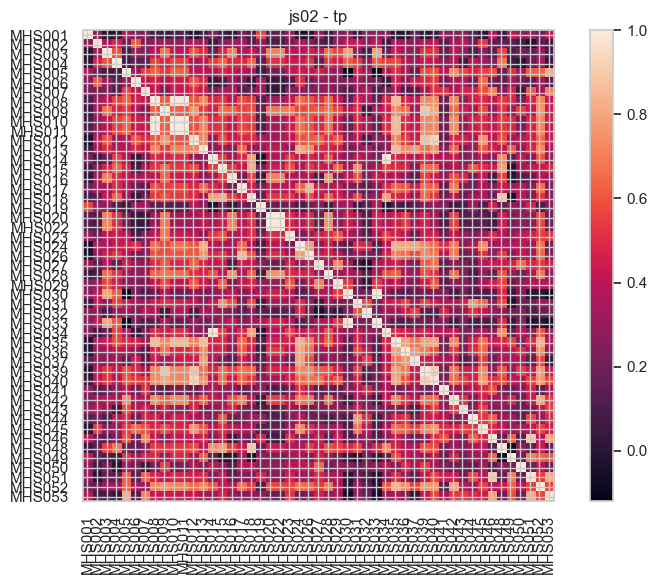

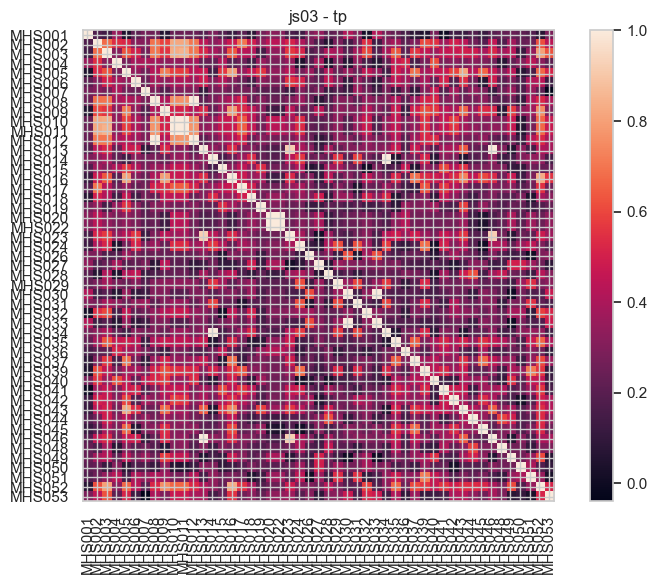

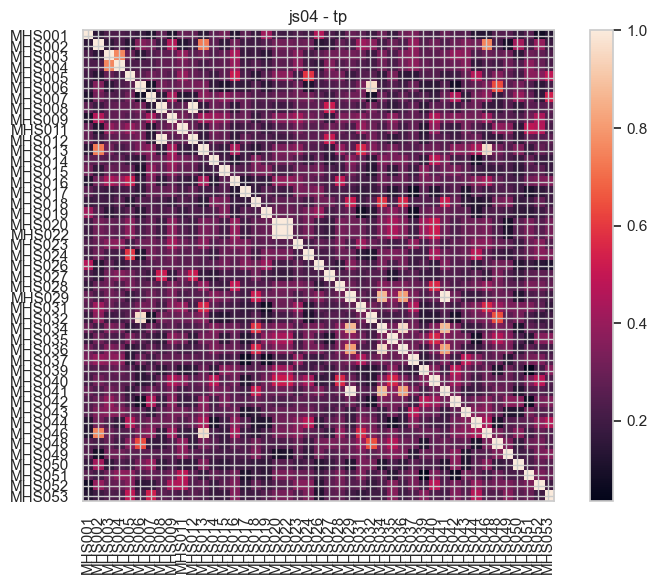

----------------------------------------------------------------------
Total Heatmap Disimpan        : 12
Preview Ditampilkan           : 3


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

def build_similarity_matrix(df_meta, embeddings):
    """Membangun matrix similarity dan label nim."""
    sim_matrix = cosine_similarity(embeddings)
    labels = df_meta["nim"].astype(str).tolist()
    return sim_matrix, labels


def plot_heatmap(sim_matrix, labels, title, save_path=None, show=True):
    """Plot heatmap similarity."""
    plt.figure(figsize=(8, 6))

    plt.imshow(sim_matrix)
    plt.colorbar()

    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)

    plt.title(title)
    plt.tight_layout()

    # Simpan gambar
    if save_path:
        plt.savefig(save_path)

    # Kontrol tampil / tidak
    if show:
        plt.show()
    else:
        plt.close()


def generate_heatmaps(input_dir, output_dir, max_preview=2):
    """Generate heatmap per file, tampilkan hanya sebagian."""
    os.makedirs(output_dir, exist_ok=True)

    preview_count = 0
    total_saved = 0

    for root, _, files in os.walk(input_dir):
        for file in files:
            if not file.endswith("_embed.pkl"):
                continue
            if file.startswith("eval_"):
                continue

            path = os.path.join(root, file)

            # Load embedding
            df_meta, embeddings, status, _ = load_embedding_file(path)
            if status != "SUCCESS" or df_meta is None or len(df_meta) < 2:
                continue

            modul = df_meta.loc[0, "modul"]
            filename = df_meta.loc[0, "file"]

            # Build similarity
            sim_matrix, labels = build_similarity_matrix(df_meta, embeddings)

            # Path simpan
            save_path = os.path.join(
                output_dir,
                f"{modul}_{filename.replace('.py','')}_heatmap.png"
            )
            # Tentukan apakah ditampilkan
            show_plot = preview_count < max_preview
            # Plot
            plot_heatmap(
                sim_matrix,
                labels,
                title=f"{modul} - {filename}",
                save_path=save_path,
                show=show_plot
            )

            if show_plot:
                preview_count += 1

            total_saved += 1

    return total_saved, preview_count


# ==============================================================================
# RUN & EXECUTION
# ==============================================================================

INPUT_DIR = DIRS['EMBEDDING_T']
OUTPUT_DIR = os.path.join(DIRS['LOGS'], "heatmap_T")
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*70)
print(f"{' HEATMAP VISUALIZATION ':^70}")
print("-"*70)
print(f"{'Input Directory':<30}: {INPUT_DIR}")
print(f"{'Output Directory':<30}: {OUTPUT_DIR}")

total_saved, preview_count = generate_heatmaps(
    INPUT_DIR,
    OUTPUT_DIR,
    max_preview=3
)

print("-"*70)
print(f"{'Total Heatmap Disimpan':<30}: {total_saved}")
print(f"{'Preview Ditampilkan':<30}: {preview_count}")
print("="*70)